In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import adjusted_rand_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

RANDOM_STATE = 42


In [8]:
current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

print("Master file:", master_file)
print("File exists:", master_file.exists())

Master file: c:\Github\retail-financial-intelligence\data\processed\retailiq_cleaned_master.csv.gz
File exists: True


In [9]:
anomaly_columns = [
    "Invoice",
    "StockCode",
    "StockCodeNormalized",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country",
    "Revenue",
    "TransactionType",
    "IsCancelled",
    "IsNegativeQuantity",
    "IsNegativePrice",
    "IsZeroPrice",
    "HasCustomerId",
    "DQ_ExtremeQuantity",
    "DQ_ExtremePrice",
    "DQ_ExtremeRevenue",
    "DQ_CriticalMissing",
    "DQ_RevenueMismatch",
    "DQ_SaleRuleViolation",
    "DQ_CancellationException",
    "DQ_OtherNeedsReview",
    "IsExactReversalPair"
]

anomaly_source_df = pd.read_csv(
    master_file,
    usecols=anomaly_columns,
    parse_dates=["InvoiceDate"],
    low_memory=False
)

print("Imported shape:", anomaly_source_df.shape)
anomaly_source_df.head()

Imported shape: (1033036, 25)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue,IsCancelled,IsNegativeQuantity,IsNegativePrice,IsZeroPrice,HasCustomerId,StockCodeNormalized,TransactionType,DQ_ExtremeQuantity,DQ_ExtremePrice,DQ_ExtremeRevenue,DQ_CriticalMissing,DQ_RevenueMismatch,DQ_SaleRuleViolation,DQ_CancellationException,DQ_OtherNeedsReview,IsExactReversalPair
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,False,False,False,False,True,85048,Sale,False,False,False,False,False,False,False,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False,False,False,False,True,79323P,Sale,False,False,False,False,False,False,False,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False,False,False,False,True,79323W,Sale,False,False,False,False,False,False,False,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,False,False,False,False,True,22041,Sale,False,False,False,False,False,False,False,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,False,False,False,False,True,21232,Sale,False,False,False,False,False,False,False,False,False


In [10]:
source_validation = pd.Series({
    "Rows": len(anomaly_source_df),
    "Missing dates": (
        anomaly_source_df[
            "InvoiceDate"
        ].isna().sum()
    ),
    "Duplicate rows": (
        anomaly_source_df.duplicated().sum()
    ),
    "Transaction types": (
        anomaly_source_df[
            "TransactionType"
        ].nunique()
    ),
    "Sale rows": (
        anomaly_source_df[
            "TransactionType"
        ].eq("Sale").sum()
    )
})

source_validation

Rows                 1033036
Missing dates              0
Duplicate rows             0
Transaction types         12
Sale rows            1003437
dtype: int64

Define valid sale candidates

The model should learn unusual behaviour within genuine sales—not simply identify cancellations and adjustments as different.

In [11]:
is_sale = (
    anomaly_source_df[
        "TransactionType"
    ].eq("Sale")
)

is_exact_reversal = (
    anomaly_source_df[
        "IsExactReversalPair"
    ].fillna(False)
)

has_critical_problem = (
    anomaly_source_df[
        "DQ_CriticalMissing"
    ].fillna(False)
    |
    anomaly_source_df[
        "DQ_RevenueMismatch"
    ].fillna(False)
    |
    anomaly_source_df[
        "DQ_SaleRuleViolation"
    ].fillna(False)
)

has_valid_numeric_values = (
    anomaly_source_df[
        [
            "Quantity",
            "Price",
            "Revenue"
        ]
    ].notna().all(axis=1)
    &
    anomaly_source_df[
        "Quantity"
    ].gt(0)
    &
    anomaly_source_df[
        "Price"
    ].gt(0)
    &
    anomaly_source_df[
        "Revenue"
    ].gt(0)
)

is_model_candidate = (
    is_sale
    & ~is_exact_reversal
    & ~has_critical_problem
    & has_valid_numeric_values
)

Create two populations:

model_sales_df: used for Isolation Forest.
rule_review_df: cancellations, adjustments, charges, tests and invalid records handled through business rules.

In [12]:
model_sales_df = anomaly_source_df.loc[
    is_model_candidate
].copy()

rule_review_df = anomaly_source_df.loc[
    ~is_model_candidate
].copy()

In [13]:
anomaly_scope_summary = pd.Series({
    "All transaction rows": len(
        anomaly_source_df
    ),
    "Isolation Forest sale rows": len(
        model_sales_df
    ),
    "Rule-review rows": len(
        rule_review_df
    ),
    "Unique sale invoices": (
        model_sales_df["Invoice"].nunique()
    ),
    "Unique sale products": (
        model_sales_df[
            "StockCodeNormalized"
        ].nunique()
    ),
    "Missing CustomerID sale rows": (
        model_sales_df[
            "CustomerID"
        ].isna().sum()
    ),
    "Extreme quantity candidates retained": (
        model_sales_df[
            "DQ_ExtremeQuantity"
        ].fillna(False).sum()
    ),
    "Extreme price candidates retained": (
        model_sales_df[
            "DQ_ExtremePrice"
        ].fillna(False).sum()
    ),
    "Extreme revenue candidates retained": (
        model_sales_df[
            "DQ_ExtremeRevenue"
        ].fillna(False).sum()
    )
})

anomaly_scope_summary

All transaction rows                    1033036
Isolation Forest sale rows               997418
Rule-review rows                          35618
Unique sale invoices                      39267
Unique sale products                       4725
Missing CustomerID sale rows             226841
Extreme quantity candidates retained        567
Extreme price candidates retained            40
Extreme revenue candidates retained         685
dtype: int64

In [14]:
assert len(model_sales_df) > 0

assert (
    len(model_sales_df)
    + len(rule_review_df)
    == len(anomaly_source_df)
)

assert model_sales_df[
    "TransactionType"
].eq("Sale").all()

assert model_sales_df[
    ["Quantity", "Price", "Revenue"]
].gt(0).all().all()

print("Stage 1 validation passed.")

Stage 1 validation passed.


Chronological train, validation and test split

Create the transaction month

In [15]:
model_sales_df[
    "InvoiceMonth"
] = model_sales_df[
    "InvoiceDate"
].dt.to_period("M")

Identify the last complete month

In [16]:
maximum_transaction_date = (
    model_sales_df[
        "InvoiceDate"
    ].max().normalize()
)

maximum_month = (
    maximum_transaction_date.to_period("M")
)

maximum_month_end = (
    maximum_month.end_time.normalize()
)

if maximum_transaction_date < maximum_month_end:
    last_complete_month = maximum_month - 1
else:
    last_complete_month = maximum_month

print(
    "Maximum transaction date:",
    maximum_transaction_date
)

print(
    "Last complete month:",
    last_complete_month
)

Maximum transaction date: 2011-12-09 00:00:00
Last complete month: 2011-11


Separate the partial final month

note:December 2011 is retained for later scoring but not used for model selection or final evaluation.

In [20]:
complete_period_df = model_sales_df.loc[
    model_sales_df[
        "InvoiceMonth"
    ].le(last_complete_month)
].copy()

partial_month_df = model_sales_df.loc[
    model_sales_df[
        "InvoiceMonth"
    ].gt(last_complete_month)
].copy()

In [21]:
print(
    "Complete-period rows:",
    len(complete_period_df)
)

print(
    "Partial-month rows:",
    len(partial_month_df)
)

print(
    "Partial months:",
    partial_month_df[
        "InvoiceMonth"
    ].unique()
)

Complete-period rows: 972690
Partial-month rows: 24728
Partial months: <PeriodArray>
['2011-12']
Length: 1, dtype: period[M]


Define validation and test windows

Use three complete months for validation and three for testing:

In [22]:
VALIDATION_MONTHS = 3
TEST_MONTHS = 3

test_start_month = (
    last_complete_month
    - (TEST_MONTHS - 1)
)

validation_start_month = (
    test_start_month
    - VALIDATION_MONTHS
)

print(
    "Validation start:",
    validation_start_month
)

print(
    "Test start:",
    test_start_month
)

Validation start: 2011-06
Test start: 2011-09


Create the datasets

In [23]:
anomaly_train_df = complete_period_df.loc[
    complete_period_df[
        "InvoiceMonth"
    ].lt(validation_start_month)
].copy()

anomaly_validation_df = complete_period_df.loc[
    complete_period_df[
        "InvoiceMonth"
    ].ge(validation_start_month)
    &
    complete_period_df[
        "InvoiceMonth"
    ].lt(test_start_month)
].copy()

anomaly_test_df = complete_period_df.loc[
    complete_period_df[
        "InvoiceMonth"
    ].ge(test_start_month)
].copy()

Review the split

In [24]:
def describe_time_split(
    split_name,
    split_df
):
    return {
        "Dataset": split_name,
        "Rows": len(split_df),
        "StartDate": (
            split_df["InvoiceDate"].min()
        ),
        "EndDate": (
            split_df["InvoiceDate"].max()
        ),
        "Months": (
            split_df[
                "InvoiceMonth"
            ].nunique()
        ),
        "Invoices": (
            split_df["Invoice"].nunique()
        )
    }

In [26]:
split_summary = pd.DataFrame([
    describe_time_split(
        "Train",
        anomaly_train_df
    ),
    describe_time_split(
        "Validation",
        anomaly_validation_df
    ),
    describe_time_split(
        "Test",
        anomaly_test_df
    ),
    describe_time_split(
        "Partial month",
        partial_month_df
    )
])

split_summary

,Dataset,Rows,StartDate,EndDate,Months,Invoices
0,Train,677670,2009-12-01 07:45:00,2011-05-31 15:53:00,18,27626
1,Validation,107201,2011-06-01 07:37:00,2011-08-31 17:30:00,3,4292
2,Test,187819,2011-09-01 08:25:00,2011-11-30 17:37:00,3,6536
3,Partial month,24728,2011-12-01 08:33:00,2011-12-09 12:50:00,1,813


Validate chronology and completeness

In [27]:
assert len(anomaly_train_df) > 0
assert len(anomaly_validation_df) > 0
assert len(anomaly_test_df) > 0

assert (
    anomaly_train_df[
        "InvoiceDate"
    ].max()
    <
    anomaly_validation_df[
        "InvoiceDate"
    ].min()
)

assert (
    anomaly_validation_df[
        "InvoiceDate"
    ].max()
    <
    anomaly_test_df[
        "InvoiceDate"
    ].min()
)

assert (
    len(anomaly_train_df)
    + len(anomaly_validation_df)
    + len(anomaly_test_df)
    + len(partial_month_df)
    == len(model_sales_df)
)

all_split_indices = pd.Index(
    np.concatenate([
        anomaly_train_df.index,
        anomaly_validation_df.index,
        anomaly_test_df.index,
        partial_month_df.index
    ])
)

assert all_split_indices.is_unique

print(
    "Chronological split validation passed."
)

Chronological split validation passed.


### Split Decision

The anomaly detector uses a chronological split rather than a random split. Historical transactions form the training population, the following three complete months are used for model selection, and the final three complete months remain untouched for final evaluation. The incomplete final month is retained only for later monitoring.

In [28]:
print(
    "Train:",
    anomaly_train_df["InvoiceMonth"].min(),
    "to",
    anomaly_train_df["InvoiceMonth"].max()
)

print(
    "Validation:",
    anomaly_validation_df["InvoiceMonth"].min(),
    "to",
    anomaly_validation_df["InvoiceMonth"].max()
)

print(
    "Test:",
    anomaly_test_df["InvoiceMonth"].min(),
    "to",
    anomaly_test_df["InvoiceMonth"].max()
)

print(
    "Partial:",
    partial_month_df["InvoiceMonth"].min(),
    "to",
    partial_month_df["InvoiceMonth"].max()
)

Train: 2009-12 to 2011-05
Validation: 2011-06 to 2011-08
Test: 2011-09 to 2011-11
Partial: 2011-12 to 2011-12


Train-derived statistical baseline

Why this baseline is needed

Before Isolation Forest, create a transparent rule:

Flag a sale when its quantity, price or revenue exceeds the 99.5th percentile observed in historical training data.

The baseline:

Gives Isolation Forest a comparison benchmark.
Is understandable to business users.
Uses training data only, avoiding future leakage.
Focuses on high-impact transaction extremes.
Is not treated as ground truth.

The lower tail is not included because low quantities and low-value sales are often normal. Product-relative price deviations will be handled during feature engineering.

Calculate thresholds from training data only

In [29]:
BASELINE_QUANTILE = 0.995

baseline_numeric_columns = [
    "Quantity",
    "Price",
    "Revenue"
]

baseline_thresholds = (
    anomaly_train_df[
        baseline_numeric_columns
    ]
    .quantile(BASELINE_QUANTILE)
)

baseline_threshold_table = (
    baseline_thresholds
    .rename("UpperThreshold")
    .reset_index()
    .rename(
        columns={
            "index": "Feature"
        }
    )
)

baseline_threshold_table[
    "Quantile"
] = BASELINE_QUANTILE

baseline_threshold_table

,Feature,UpperThreshold,Quantile
0,Quantity,192.0,0.995
1,Price,21.7,0.995
2,Revenue,275.0,0.995


Create a reusable baseline function

In [30]:
def apply_statistical_baseline(
    input_df,
    thresholds
):
    result_df = input_df.copy()

    result_df[
        "Baseline_ExtremeQuantity"
    ] = (
        result_df["Quantity"]
        > thresholds["Quantity"]
    )

    result_df[
        "Baseline_ExtremePrice"
    ] = (
        result_df["Price"]
        > thresholds["Price"]
    )

    result_df[
        "Baseline_ExtremeRevenue"
    ] = (
        result_df["Revenue"]
        > thresholds["Revenue"]
    )

    baseline_flag_columns = [
        "Baseline_ExtremeQuantity",
        "Baseline_ExtremePrice",
        "Baseline_ExtremeRevenue"
    ]

    result_df[
        "BaselineFlagCount"
    ] = result_df[
        baseline_flag_columns
    ].sum(axis=1)

    result_df[
        "BaselineAnomaly"
    ] = (
        result_df[
            "BaselineFlagCount"
        ] > 0
    )

    result_df[
        "BaselineReason"
    ] = np.select(
        [
            result_df[
                "BaselineFlagCount"
            ].gt(1),
            result_df[
                "Baseline_ExtremeRevenue"
            ],
            result_df[
                "Baseline_ExtremeQuantity"
            ],
            result_df[
                "Baseline_ExtremePrice"
            ]
        ],
        [
            "Multiple extreme measures",
            "Extreme revenue",
            "Extreme quantity",
            "Extreme price"
        ],
        default="Not flagged"
    )

    result_df[
        "ExistingDQExtreme"
    ] = (
        result_df[
            "DQ_ExtremeQuantity"
        ].fillna(False)
        |
        result_df[
            "DQ_ExtremePrice"
        ].fillna(False)
        |
        result_df[
            "DQ_ExtremeRevenue"
        ].fillna(False)
    )

    return result_df

Apply the same thresholds to every period

In [33]:
anomaly_train_df = (
    apply_statistical_baseline(
        anomaly_train_df,
        baseline_thresholds
    )
)

anomaly_validation_df = (
    apply_statistical_baseline(
        anomaly_validation_df,
        baseline_thresholds
    )
)

anomaly_test_df = (
    apply_statistical_baseline(
        anomaly_test_df,
        baseline_thresholds
    )
)

partial_month_df = (
    apply_statistical_baseline(
        partial_month_df,
        baseline_thresholds
    )
)

Compare baseline results across periods

In [34]:
def summarize_baseline(
    dataset_name,
    dataset
):
    baseline_count = int(
        dataset[
            "BaselineAnomaly"
        ].sum()
    )

    dq_count = int(
        dataset[
            "ExistingDQExtreme"
        ].sum()
    )

    overlap_count = int(
        (
            dataset["BaselineAnomaly"]
            & dataset["ExistingDQExtreme"]
        ).sum()
    )

    return {
        "Dataset": dataset_name,
        "Rows": len(dataset),
        "BaselineAnomalies": baseline_count,
        "BaselineRatePercent": (
            baseline_count
            / len(dataset)
            * 100
            if len(dataset) > 0
            else np.nan
        ),
        "ExistingDQExtremeRows": dq_count,
        "BaselineDQOverlap": overlap_count
    }

In [35]:
baseline_split_summary = pd.DataFrame([
    summarize_baseline(
        "Train",
        anomaly_train_df
    ),
    summarize_baseline(
        "Validation",
        anomaly_validation_df
    ),
    summarize_baseline(
        "Test",
        anomaly_test_df
    ),
    summarize_baseline(
        "Partial month",
        partial_month_df
    )
])

baseline_split_summary

,Dataset,Rows,BaselineAnomalies,BaselineRatePercent,ExistingDQExtremeRows,BaselineDQOverlap
0,Train,677670,8103,1.195715,773,773
1,Validation,107201,1216,1.134318,116,116
2,Test,187819,1751,0.932281,171,171
3,Partial month,24728,231,0.934164,26,26


Inspect test-period baseline anomalies

In [36]:
baseline_test_examples = (
    anomaly_test_df.loc[
        anomaly_test_df[
            "BaselineAnomaly"
        ],
        [
            "Invoice",
            "InvoiceDate",
            "StockCodeNormalized",
            "Description",
            "Quantity",
            "Price",
            "Revenue",
            "BaselineReason",
            "ExistingDQExtreme"
        ]
    ]
    .sort_values(
        "Revenue",
        ascending=False
    )
)

baseline_test_examples.head(30)

,Invoice,InvoiceDate,StockCodeNormalized,Description,Quantity,Price,Revenue,BaselineReason,ExistingDQExtreme
842021,567423,2011-09-20 11:05:00,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,Multiple extreme measures,True
914482,573003,2011-10-27 12:11:00,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Multiple extreme measures,True
960033,576365,2011-11-14 17:55:00,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,6.95,4781.60,Multiple extreme measures,True
1002849,579498,2011-11-29 15:52:00,23084,RABBIT NIGHT LIGHT,2040,1.79,3651.60,Multiple extreme measures,True
842019,567423,2011-09-20 11:05:00,22722,SET OF 6 SPICE TINS PANTRY DESIGN,852,4.25,3621.00,Multiple extreme measures,True
939547,574941,2011-11-07 17:42:00,22197,POPCORN HOLDER,1820,1.95,3549.00,Multiple extreme measures,True
939552,574941,2011-11-07 17:42:00,22086,PAPER CHAIN KIT 50'S CHRISTMAS,478,6.95,3322.10,Multiple extreme measures,True
904261,572209,2011-10-21 12:08:00,23556,LANDMARK FRAME COVENT GARDEN,300,10.95,3285.00,Multiple extreme measures,True
904262,572209,2011-10-21 12:08:00,23554,LANDMARK FRAME OXFORD STREET,300,10.95,3285.00,Multiple extreme measures,True
904266,572209,2011-10-21 12:08:00,23553,LANDMARK FRAME CAMDEN TOWN,300,10.95,3285.00,Multiple extreme measures,True


Validate the baseline

In [37]:
assert baseline_thresholds.notna().all()

assert anomaly_train_df[
    "BaselineAnomaly"
].notna().all()

assert anomaly_validation_df[
    "BaselineAnomaly"
].notna().all()

assert anomaly_test_df[
    "BaselineAnomaly"
].notna().all()

assert (
    baseline_thresholds
    == anomaly_train_df[
        baseline_numeric_columns
    ].quantile(BASELINE_QUANTILE)
).all()

print(
    "Train-derived statistical baseline passed."
)

Train-derived statistical baseline passed.


### Baseline Definition

The statistical baseline flags transactions above the training period’s 99.5th percentile for quantity, price or revenue. The thresholds are learned once from historical training data and applied unchanged to validation and test periods. Existing data-quality flags are retained for comparison but are not treated as confirmed anomaly labels.

Leakage-safe anomaly feature engineering

Why these features are needed

Raw quantity, price and revenue alone cannot distinguish between:

A genuinely unusual transaction.
A normally expensive product.
A regular wholesale customer.
A product normally purchased in large quantities.

We therefore compare each transaction with historical product and customer behaviour.

All historical reference values are calculated from anomaly_train_df only.

Fit historical reference statistics

In [38]:
def fit_anomaly_references(training_df):
    product_training_data = (
        training_df
        .dropna(
            subset=["StockCodeNormalized"]
        )
    )

    product_reference = (
        product_training_data
        .groupby("StockCodeNormalized")
        .agg(
            ProductInvoiceFrequency=(
                "Invoice",
                "nunique"
            ),
            ProductMedianPrice=(
                "Price",
                "median"
            ),
            ProductMedianQuantity=(
                "Quantity",
                "median"
            )
        )
    )

    customer_training_data = (
        training_df
        .dropna(
            subset=["CustomerID"]
        )
    )

    customer_invoice_frequency = (
        customer_training_data
        .groupby("CustomerID")["Invoice"]
        .nunique()
        .rename(
            "CustomerInvoiceFrequency"
        )
    )

    customer_order_values = (
        customer_training_data
        .groupby(
            [
                "CustomerID",
                "Invoice"
            ]
        )["Revenue"]
        .sum()
        .groupby("CustomerID")
        .median()
        .rename(
            "CustomerMedianOrderValue"
        )
    )

    training_order_values = (
        training_df
        .groupby("Invoice")["Revenue"]
        .sum()
    )

    return {
        "product_reference": (
            product_reference
        ),
        "customer_invoice_frequency": (
            customer_invoice_frequency
        ),
        "customer_order_values": (
            customer_order_values
        ),
        "global_median_price": (
            training_df["Price"].median()
        ),
        "global_median_quantity": (
            training_df["Quantity"].median()
        ),
        "global_median_order_value": (
            training_order_values.median()
        )
    }

In [39]:
anomaly_references = (
    fit_anomaly_references(
        anomaly_train_df
    )
)

anomaly_references[
    "product_reference"
].head()

,ProductInvoiceFrequency,ProductMedianPrice,ProductMedianQuantity
StockCodeNormalized,,,
10002,356,0.85,12.0
10002R,3,5.17,1.0
10080,6,0.85,1.0
10109,1,0.42,4.0
10120,54,0.21,4.0


Inspect the fallback values:

In [40]:
reference_summary = pd.Series({
    "Products in training": len(
        anomaly_references[
            "product_reference"
        ]
    ),
    "Customers in training": len(
        anomaly_references[
            "customer_invoice_frequency"
        ]
    ),
    "Global median price": (
        anomaly_references[
            "global_median_price"
        ]
    ),
    "Global median quantity": (
        anomaly_references[
            "global_median_quantity"
        ]
    ),
    "Global median order value": (
        anomaly_references[
            "global_median_order_value"
        ]
    )
})

reference_summary

Products in training         4293.0
Customers in training        4899.0
Global median price             2.1
Global median quantity          3.0
Global median order value     295.0
dtype: float64

Define the final model features

In [41]:
anomaly_feature_columns = [
    "LogQuantity",
    "LogPrice",
    "LogRevenue",
    "LogInvoiceLineCount",
    "LogInvoiceTotalRevenue",
    "LogProductInvoiceFrequency",
    "LogCustomerInvoiceFrequency",
    "LogPriceToProductMedian",
    "LogQuantityToProductMedian",
    "LogOrderValueToCustomerMedian",
    "HasKnownCustomer",
    "HourSin",
    "HourCos",
    "WeekdaySin",
    "WeekdayCos",
    "MonthSin",
    "MonthCos"
]

Create the feature-building function

In [42]:
def build_anomaly_features(
    input_df,
    references
):
    features_df = pd.DataFrame(
        index=input_df.index
    )

    product_reference = references[
        "product_reference"
    ]

    customer_frequency_reference = references[
        "customer_invoice_frequency"
    ]

    customer_value_reference = references[
        "customer_order_values"
    ]

    # Raw monetary features with skew reduction
    features_df["LogQuantity"] = np.log1p(
        input_df["Quantity"]
    )

    features_df["LogPrice"] = np.log1p(
        input_df["Price"]
    )

    features_df["LogRevenue"] = np.log1p(
        input_df["Revenue"]
    )

    # Invoice-level context available when
    # reviewing a completed transaction
    invoice_line_count = (
        input_df
        .groupby("Invoice")["Invoice"]
        .transform("size")
    )

    invoice_total_revenue = (
        input_df
        .groupby("Invoice")["Revenue"]
        .transform("sum")
    )

    features_df[
        "LogInvoiceLineCount"
    ] = np.log1p(invoice_line_count)

    features_df[
        "LogInvoiceTotalRevenue"
    ] = np.log1p(invoice_total_revenue)

    # Historical product behaviour
    product_frequency = (
        input_df["StockCodeNormalized"]
        .map(
            product_reference[
                "ProductInvoiceFrequency"
            ]
        )
        .fillna(0)
    )

    product_median_price = (
        input_df["StockCodeNormalized"]
        .map(
            product_reference[
                "ProductMedianPrice"
            ]
        )
        .fillna(
            references[
                "global_median_price"
            ]
        )
    )

    product_median_quantity = (
        input_df["StockCodeNormalized"]
        .map(
            product_reference[
                "ProductMedianQuantity"
            ]
        )
        .fillna(
            references[
                "global_median_quantity"
            ]
        )
    )

    features_df[
        "LogProductInvoiceFrequency"
    ] = np.log1p(product_frequency)

    features_df[
        "LogPriceToProductMedian"
    ] = np.log(
        input_df["Price"].clip(lower=1e-6)
        /
        product_median_price.clip(
            lower=1e-6
        )
    )

    features_df[
        "LogQuantityToProductMedian"
    ] = np.log(
        input_df[
            "Quantity"
        ].clip(lower=1e-6)
        /
        product_median_quantity.clip(
            lower=1e-6
        )
    )

    # Historical customer behaviour
    customer_frequency = (
        input_df["CustomerID"]
        .map(
            customer_frequency_reference
        )
        .fillna(0)
    )

    customer_median_order_value = (
        input_df["CustomerID"]
        .map(
            customer_value_reference
        )
        .fillna(
            references[
                "global_median_order_value"
            ]
        )
    )

    features_df[
        "LogCustomerInvoiceFrequency"
    ] = np.log1p(customer_frequency)

    features_df[
        "LogOrderValueToCustomerMedian"
    ] = np.log(
        invoice_total_revenue.clip(
            lower=1e-6
        )
        /
        customer_median_order_value.clip(
            lower=1e-6
        )
    )

    features_df[
        "HasKnownCustomer"
    ] = (
        input_df["CustomerID"]
        .notna()
        .astype("int8")
    )

    # Cyclical time features
    transaction_hour = (
        input_df["InvoiceDate"].dt.hour
    )

    transaction_weekday = (
        input_df[
            "InvoiceDate"
        ].dt.dayofweek
    )

    transaction_month = (
        input_df["InvoiceDate"].dt.month
    )

    features_df["HourSin"] = np.sin(
        2 * np.pi
        * transaction_hour / 24
    )

    features_df["HourCos"] = np.cos(
        2 * np.pi
        * transaction_hour / 24
    )

    features_df["WeekdaySin"] = np.sin(
        2 * np.pi
        * transaction_weekday / 7
    )

    features_df["WeekdayCos"] = np.cos(
        2 * np.pi
        * transaction_weekday / 7
    )

    features_df["MonthSin"] = np.sin(
        2 * np.pi
        * transaction_month / 12
    )

    features_df["MonthCos"] = np.cos(
        2 * np.pi
        * transaction_month / 12
    )

    return (
        features_df[
            anomaly_feature_columns
        ]
        .astype("float32")
    )

Build features for every period

Use the same training references for every dataset:

In [43]:
X_anomaly_train = (
    build_anomaly_features(
        anomaly_train_df,
        anomaly_references
    )
)

X_anomaly_validation = (
    build_anomaly_features(
        anomaly_validation_df,
        anomaly_references
    )
)

X_anomaly_test = (
    build_anomaly_features(
        anomaly_test_df,
        anomaly_references
    )
)

X_anomaly_partial = (
    build_anomaly_features(
        partial_month_df,
        anomaly_references
    )
)

Validate the feature matrices

In [44]:
feature_validation = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test",
        "Partial month"
    ],
    "Rows": [
        len(X_anomaly_train),
        len(X_anomaly_validation),
        len(X_anomaly_test),
        len(X_anomaly_partial)
    ],
    "Features": [
        X_anomaly_train.shape[1],
        X_anomaly_validation.shape[1],
        X_anomaly_test.shape[1],
        X_anomaly_partial.shape[1]
    ],
    "MissingValues": [
        X_anomaly_train.isna().sum().sum(),
        X_anomaly_validation.isna().sum().sum(),
        X_anomaly_test.isna().sum().sum(),
        X_anomaly_partial.isna().sum().sum()
    ],
    "InfiniteValues": [
        np.isinf(
            X_anomaly_train
        ).sum().sum(),
        np.isinf(
            X_anomaly_validation
        ).sum().sum(),
        np.isinf(
            X_anomaly_test
        ).sum().sum(),
        np.isinf(
            X_anomaly_partial
        ).sum().sum()
    ]
})

feature_validation

,Dataset,Rows,Features,MissingValues,InfiniteValues
0,Train,677670,17,0,0
1,Validation,107201,17,0,0
2,Test,187819,17,0,0
3,Partial month,24728,17,0,0


In [45]:
assert X_anomaly_train.index.equals(
    anomaly_train_df.index
)

assert X_anomaly_validation.index.equals(
    anomaly_validation_df.index
)

assert X_anomaly_test.index.equals(
    anomaly_test_df.index
)

assert list(
    X_anomaly_train.columns
) == anomaly_feature_columns

assert (
    X_anomaly_train
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    X_anomaly_train.to_numpy()
).all()

print(
    "Leakage-safe feature validation passed."
)

Leakage-safe feature validation passed.


In [46]:
X_anomaly_train.describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
LogQuantity,677670.0,1.714328,0.995582,0.693147,0.693147,0.693147,1.386294e+00,3.433987,4.691348,9.860214
LogPrice,677670.0,1.262397,0.618185,0.001000,0.254642,0.350657,1.131402e+00,2.393339,2.889260,7.054579
LogRevenue,677670.0,2.366471,0.989559,0.001000,0.593327,0.815365,2.410542e+00,4.107590,5.171620,9.668992
LogInvoiceLineCount,677670.0,3.865423,1.083547,0.693147,1.386294,2.302585,3.761200e+00,6.003887,6.342122,6.514713
LogInvoiceTotalRevenue,677670.0,6.330438,1.065814,0.173953,3.939638,4.823100,6.185838e+00,8.290842,8.775351,10.816693
LogProductInvoiceFrequency,677670.0,5.843439,1.079014,0.693147,2.833213,3.912023,5.968708e+00,7.323171,7.952967,8.367533
LogCustomerInvoiceFrequency,677670.0,1.888991,1.410938,0.000000,0.000000,0.000000,1.945910e+00,4.691348,5.283204,5.446737
LogPriceToProductMedian,677670.0,0.103247,0.342013,-4.417635,-0.793231,-0.154151,0.000000e+00,0.720762,0.967744,7.921216
LogQuantityToProductMedian,677670.0,0.000046,1.136772,-5.120983,-2.484907,-1.791759,0.000000e+00,1.791759,3.178054,8.371011
LogOrderValueToCustomerMedian,677670.0,0.530452,0.954676,-7.347707,-1.558223,-0.543836,2.509288e-01,2.500988,3.062624,5.515260


In [47]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

candidate_max_samples = [256, 1024]

candidate_anomaly_rates = [
    0.005,   # 0.5%
    0.010,   # 1.0%
    0.020    # 2.0%
]

candidate_models = {}
candidate_results = []

validation_baseline_flags = (
    anomaly_validation_df[
        "BaselineAnomaly"
    ]
    .reindex(X_anomaly_validation.index)
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

validation_baseline_count = int(
    validation_baseline_flags.sum()
)


def calculate_anomaly_scores(
    fitted_pipeline,
    feature_data
):
    transformed_data = (
        fitted_pipeline
        .named_steps["imputer"]
        .transform(feature_data)
    )

    raw_scores = (
        fitted_pipeline
        .named_steps["isolation_forest"]
        .score_samples(transformed_data)
    )

    # Higher value = more anomalous
    return -raw_scores


def safe_percentage(numerator, denominator):
    if denominator == 0:
        return np.nan

    return numerator / denominator * 100

In [48]:
for max_samples_value in candidate_max_samples:

    print(
        f"Fitting Isolation Forest: "
        f"max_samples={max_samples_value}"
    )

    candidate_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "isolation_forest",
                IsolationForest(
                    n_estimators=250,
                    max_samples=max_samples_value,
                    contamination="auto",
                    max_features=1.0,
                    bootstrap=False,
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    candidate_pipeline.fit(X_anomaly_train)

    training_scores = calculate_anomaly_scores(
        candidate_pipeline,
        X_anomaly_train
    )

    validation_scores = calculate_anomaly_scores(
        candidate_pipeline,
        X_anomaly_validation
    )

    candidate_models[max_samples_value] = (
        candidate_pipeline
    )

    for anomaly_rate in candidate_anomaly_rates:

        score_threshold = float(
            np.quantile(
                training_scores,
                1 - anomaly_rate
            )
        )

        training_flags = (
            training_scores >= score_threshold
        )

        validation_flags = (
            validation_scores >= score_threshold
        )

        validation_anomaly_count = int(
            validation_flags.sum()
        )

        overlap_count = int(
            (
                validation_flags
                & validation_baseline_flags
            ).sum()
        )

        union_count = int(
            (
                validation_flags
                | validation_baseline_flags
            ).sum()
        )

        actual_training_rate = (
            training_flags.mean() * 100
        )

        validation_rate = (
            validation_flags.mean() * 100
        )

        candidate_results.append(
            {
                "MaxSamples": max_samples_value,
                "TargetTrainRatePercent": (
                    anomaly_rate * 100
                ),
                "ActualTrainRatePercent": (
                    actual_training_rate
                ),
                "ValidationRatePercent": (
                    validation_rate
                ),
                "ValidationRateShiftPP": (
                    validation_rate
                    - actual_training_rate
                ),
                "ValidationAnomalies": (
                    validation_anomaly_count
                ),
                "BaselineAnomalies": (
                    validation_baseline_count
                ),
                "OverlapCount": overlap_count,
                "BaselineCoveragePercent": (
                    safe_percentage(
                        overlap_count,
                        validation_baseline_count
                    )
                ),
                "ModelFlagsAlsoBaselinePercent": (
                    safe_percentage(
                        overlap_count,
                        validation_anomaly_count
                    )
                ),
                "JaccardWithBaseline": (
                    overlap_count / union_count
                    if union_count > 0
                    else np.nan
                ),
                "ScoreThreshold": score_threshold
            }
        )

Fitting Isolation Forest: max_samples=256
Fitting Isolation Forest: max_samples=1024


In [49]:
anomaly_candidate_results = (
    pd.DataFrame(candidate_results)
    .sort_values(
        [
            "TargetTrainRatePercent",
            "MaxSamples"
        ]
    )
    .reset_index(drop=True)
)

anomaly_candidate_results.round(4)

,MaxSamples,TargetTrainRatePercent,ActualTrainRatePercent,ValidationRatePercent,ValidationRateShiftPP,ValidationAnomalies,BaselineAnomalies,OverlapCount,BaselineCoveragePercent,ModelFlagsAlsoBaselinePercent,JaccardWithBaseline,ScoreThreshold
0,256,0.5,0.5001,0.9608,0.4607,1030,1216,440,36.1842,42.7184,0.2436,0.6022
1,1024,0.5,0.5001,0.8423,0.3422,903,1216,387,31.8257,42.8571,0.2234,0.5998
2,256,1.0,1.0000,1.8806,0.8805,2016,1216,623,51.2336,30.9028,0.2388,0.5864
3,1024,1.0,1.0000,1.9393,0.9393,2079,1216,567,46.6283,27.2727,0.2078,0.5798
4,256,2.0,2.0001,4.0690,2.0689,4362,1216,835,68.6678,19.1426,0.1760,0.5698
5,1024,2.0,2.0001,4.7845,2.7844,5129,1216,841,69.1612,16.3970,0.1528,0.5579


Select and inspect the candidate

In [50]:
selected_max_samples = 256
selected_target_rate = 0.01

selected_candidate_row = (
    anomaly_candidate_results.loc[
        (
            anomaly_candidate_results[
                "MaxSamples"
            ].eq(selected_max_samples)
        )
        &
        (
            np.isclose(
                anomaly_candidate_results[
                    "TargetTrainRatePercent"
                ],
                selected_target_rate * 100
            )
        )
    ]
    .iloc[0]
)

selected_anomaly_pipeline = (
    candidate_models[selected_max_samples]
)

selected_score_threshold = float(
    selected_candidate_row["ScoreThreshold"]
)

print(
    "Selected max_samples:",
    selected_max_samples
)

print(
    "Selected training anomaly rate:",
    f"{selected_target_rate:.1%}"
)

print(
    "Selected score threshold:",
    round(selected_score_threshold, 4)
)

Selected max_samples: 256
Selected training anomaly rate: 1.0%
Selected score threshold: 0.5864


Score the validation period

In [51]:
validation_if_scores = calculate_anomaly_scores(
    selected_anomaly_pipeline,
    X_anomaly_validation
)

anomaly_validation_scored_df = (
    anomaly_validation_df.copy()
)

anomaly_validation_scored_df[
    "IFAnomalyScore"
] = pd.Series(
    validation_if_scores,
    index=X_anomaly_validation.index
).reindex(
    anomaly_validation_scored_df.index
)

anomaly_validation_scored_df[
    "IFAnomaly"
] = (
    anomaly_validation_scored_df[
        "IFAnomalyScore"
    ] >= selected_score_threshold
)

anomaly_validation_scored_df[
    "IFScorePercentile"
] = (
    anomaly_validation_scored_df[
        "IFAnomalyScore"
    ]
    .rank(pct=True)
    .mul(100)
)

Higher IFAnomalyScore means the transaction appears more unusual.


Compare the model with the baseline

In [52]:
model_flag = (
    anomaly_validation_scored_df[
        "IFAnomaly"
    ]
)

baseline_flag = (
    anomaly_validation_scored_df[
        "BaselineAnomaly"
    ].fillna(False)
)

anomaly_validation_scored_df[
    "DetectionSource"
] = np.select(
    [
        model_flag & baseline_flag,
        model_flag & ~baseline_flag,
        ~model_flag & baseline_flag
    ],
    [
        "Both",
        "Isolation Forest only",
        "Statistical baseline only"
    ],
    default="Not flagged"
)

detection_summary = (
    anomaly_validation_scored_df[
        "DetectionSource"
    ]
    .value_counts()
    .rename_axis("DetectionSource")
    .reset_index(name="Transactions")
)

detection_summary[
    "SharePercent"
] = (
    detection_summary["Transactions"]
    / len(anomaly_validation_scored_df)
    * 100
)

detection_summary.round(3)

,DetectionSource,Transactions,SharePercent
0,Not flagged,104592,97.566
1,Isolation Forest only,1393,1.299
2,Both,623,0.581
3,Statistical baseline only,593,0.553


In [53]:
validation_review_columns = [
    "Invoice",
    "InvoiceDate",
    "StockCodeNormalized",
    "Description",
    "CustomerID",
    "Quantity",
    "Price",
    "Revenue",
    "IFAnomalyScore",
    "IFScorePercentile",
    "BaselineAnomaly",
    "BaselineReason",
    "ExistingDQExtreme",
    "DetectionSource"
]

top_validation_anomalies = (
    anomaly_validation_scored_df.loc[
        anomaly_validation_scored_df[
            "IFAnomaly"
        ],
        validation_review_columns
    ]
    .sort_values(
        "IFAnomalyScore",
        ascending=False
    )
)

top_validation_anomalies.head(30)

,Invoice,InvoiceDate,StockCodeNormalized,Description,CustomerID,Quantity,Price,Revenue,IFAnomalyScore,IFScorePercentile,BaselineAnomaly,BaselineReason,ExistingDQExtreme,DetectionSource
736336,558262,2011-06-28 08:45:00,23121,PACK OF 6 COCKTAIL PARASOL STRAWS,14646.0,288,0.36,103.68,0.671920,100.000000,True,Extreme quantity,False,Both
798689,563590,2011-08-17 20:02:00,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,17450.0,352,5.15,1812.80,0.667163,99.999067,True,Multiple extreme measures,True,Both
724646,557125,2011-06-16 18:40:00,23286,BLUE VINTAGE SPOT BEAKER,17450.0,588,0.72,423.36,0.666131,99.997202,True,Multiple extreme measures,False,Both
724648,557125,2011-06-16 18:40:00,23288,GREEN VINTAGE SPOT BEAKER,17450.0,612,0.72,440.64,0.666131,99.997202,True,Multiple extreme measures,True,Both
724647,557125,2011-06-16 18:40:00,23285,PINK VINTAGE SPOT BEAKER,17450.0,612,0.72,440.64,0.666131,99.997202,True,Multiple extreme measures,True,Both
785352,562439,2011-08-04 18:06:00,23215,JINGLE BELL HEART ANTIQUE SILVER,12931.0,576,1.79,1031.04,0.664708,99.995336,True,Multiple extreme measures,True,Both
793021,563076,2011-08-11 16:12:00,23307,SET OF 60 PANTRY DESIGN CAKE CASES,14646.0,240,0.42,100.80,0.664707,99.994403,True,Extreme quantity,False,Both
798914,563614,2011-08-18 08:51:00,23353,6 GIFT TAGS VINTAGE CHRISTMAS,12415.0,216,0.72,155.52,0.663152,99.993470,True,Extreme quantity,False,Both
716282,556267,2011-06-09 19:33:00,85213,MINI ZINC GARDEN DECORATIONS,13694.0,480,0.29,139.20,0.663113,99.992537,True,Extreme quantity,False,Both
716280,556267,2011-06-09 19:33:00,85212,MINI PAINTED GARDEN DECORATION,13694.0,504,0.29,146.16,0.662345,99.991605,True,Extreme quantity,False,Both


In [54]:
model_only_anomalies = (
    anomaly_validation_scored_df.loc[
        anomaly_validation_scored_df[
            "DetectionSource"
        ].eq("Isolation Forest only"),
        validation_review_columns
    ]
    .sort_values(
        "IFAnomalyScore",
        ascending=False
    )
)

model_only_anomalies.head(30)

,Invoice,InvoiceDate,StockCodeNormalized,Description,CustomerID,Quantity,Price,Revenue,IFAnomalyScore,IFScorePercentile,BaselineAnomaly,BaselineReason,ExistingDQExtreme,DetectionSource
798920,563614,2011-08-18 08:51:00,23326,HANGING MINI COLOURED BOTTLES,12415.0,192,0.55,105.60,0.657770,99.979478,False,Not flagged,False,Isolation Forest only
736334,558262,2011-06-28 08:45:00,23119,PACK OF 6 LARGE FRUIT STRAWS,14646.0,144,0.53,76.32,0.656795,99.975746,False,Not flagged,False,Isolation Forest only
793078,563076,2011-08-11 16:12:00,23291,DOLLY GIRL CHILDRENS CUP,14646.0,192,1.05,201.60,0.655860,99.968284,False,Not flagged,False,Isolation Forest only
793084,563076,2011-08-11 16:12:00,23275,SET OF 3 HANGING OWLS OLLIE BEAK,14646.0,192,1.04,199.68,0.655860,99.968284,False,Not flagged,False,Isolation Forest only
793079,563076,2011-08-11 16:12:00,23292,SPACEBOY CHILDRENS CUP,14646.0,192,1.05,201.60,0.655860,99.968284,False,Not flagged,False,Isolation Forest only
736335,558262,2011-06-28 08:45:00,23122,PARTY CHARMS 50 PIECES,14646.0,144,0.72,103.68,0.655794,99.965952,False,Not flagged,False,Isolation Forest only
736337,558262,2011-06-28 08:45:00,23123,COCKTAIL SWORDS 50 PIECES,14646.0,144,0.72,103.68,0.655794,99.965952,False,Not flagged,False,Isolation Forest only
747988,559166,2011-07-06 16:53:00,16219,HOUSE SHAPE PENCIL SHARPENER,NaN,24,0.06,1.44,0.654949,99.960821,False,Not flagged,False,Isolation Forest only
793019,563076,2011-08-11 16:12:00,23270,SET OF 2 CERAMIC PAINTED HEARTS,14646.0,192,1.25,240.00,0.654472,99.958956,False,Not flagged,False,Isolation Forest only
716272,556267,2011-06-09 19:33:00,21635,MADRAS NOTEBOOK LARGE,13694.0,144,1.25,180.00,0.653002,99.952426,False,Not flagged,False,Isolation Forest only


In [55]:
anomaly_development_df = (
    pd.concat(
        [
            anomaly_train_df,
            anomaly_validation_df
        ],
        axis=0
    )
    .sort_values("InvoiceDate")
    .copy()
)

print(
    "Development period:",
    anomaly_development_df[
        "InvoiceMonth"
    ].min(),
    "to",
    anomaly_development_df[
        "InvoiceMonth"
    ].max()
)

print(
    "Development rows:",
    len(anomaly_development_df)
)

print(
    "Test rows:",
    len(anomaly_test_df)
)

Development period: 2009-12 to 2011-08
Development rows: 784871
Test rows: 187819


In [56]:
final_anomaly_references = (
    fit_anomaly_references(
        anomaly_development_df
    )
)

X_anomaly_development = (
    build_anomaly_features(
        anomaly_development_df,
        final_anomaly_references
    )
)

X_anomaly_final_test = (
    build_anomaly_features(
        anomaly_test_df,
        final_anomaly_references
    )
)

assert list(
    X_anomaly_development.columns
) == list(
    X_anomaly_final_test.columns
)

assert not X_anomaly_development.isna().any().any()
assert not X_anomaly_final_test.isna().any().any()

print(
    "Development feature shape:",
    X_anomaly_development.shape
)

print(
    "Test feature shape:",
    X_anomaly_final_test.shape
)

Development feature shape: (784871, 17)
Test feature shape: (187819, 17)


Fit the final Isolation Forest

In [57]:
final_anomaly_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "isolation_forest",
            IsolationForest(
                n_estimators=250,
                max_samples=256,
                contamination="auto",
                max_features=1.0,
                bootstrap=False,
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_anomaly_pipeline.fit(
    X_anomaly_development
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('isolation_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['LogQuantity','LogPrice','LogRevenue',...,'WeekdayCos','MonthSin', 'MonthCos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or obje

In [58]:
development_if_scores = (
    calculate_anomaly_scores(
        final_anomaly_pipeline,
        X_anomaly_development
    )
)

test_if_scores = calculate_anomaly_scores(
    final_anomaly_pipeline,
    X_anomaly_final_test
)

final_score_threshold = float(
    np.quantile(
        development_if_scores,
        0.99
    )
)

print(
    "Final score threshold:",
    round(final_score_threshold, 4)
)

Final score threshold: 0.5822


Refit the statistical baseline

In [59]:
final_baseline_thresholds = (
    anomaly_development_df[
        ["Quantity", "Price", "Revenue"]
    ]
    .quantile(BASELINE_QUANTILE)
    .to_dict()
)

anomaly_test_scored_df = (
    apply_statistical_baseline(
        anomaly_test_df,
        final_baseline_thresholds
    )
)

Add Isolation Forest results:

In [60]:
anomaly_test_scored_df[
    "IFAnomalyScore"
] = pd.Series(
    test_if_scores,
    index=X_anomaly_final_test.index
).reindex(
    anomaly_test_scored_df.index
)

anomaly_test_scored_df[
    "IFAnomaly"
] = (
    anomaly_test_scored_df[
        "IFAnomalyScore"
    ] >= final_score_threshold
)

anomaly_test_scored_df[
    "IFScorePercentile"
] = (
    anomaly_test_scored_df[
        "IFAnomalyScore"
    ]
    .rank(pct=True)
    .mul(100)
)

Evaluate the untouched test period

In [61]:
test_model_flags = (
    anomaly_test_scored_df[
        "IFAnomaly"
    ].astype(bool)
)

test_baseline_flags = (
    anomaly_test_scored_df[
        "BaselineAnomaly"
    ]
    .fillna(False)
    .astype(bool)
)

test_overlap = int(
    (
        test_model_flags
        & test_baseline_flags
    ).sum()
)

test_union = int(
    (
        test_model_flags
        | test_baseline_flags
    ).sum()
)

development_anomaly_rate = (
    (
        development_if_scores
        >= final_score_threshold
    ).mean() * 100
)

test_anomaly_rate = (
    test_model_flags.mean() * 100
)

In [62]:
test_evaluation = pd.Series({
    "Development rows": (
        len(anomaly_development_df)
    ),
    "Test rows": (
        len(anomaly_test_scored_df)
    ),
    "Development anomaly rate (%)": (
        development_anomaly_rate
    ),
    "Test anomaly rate (%)": (
        test_anomaly_rate
    ),
    "Test rate shift (percentage points)": (
        test_anomaly_rate
        - development_anomaly_rate
    ),
    "Test model anomalies": (
        int(test_model_flags.sum())
    ),
    "Test baseline anomalies": (
        int(test_baseline_flags.sum())
    ),
    "Overlap": test_overlap,
    "Baseline coverage (%)": (
        safe_percentage(
            test_overlap,
            int(test_baseline_flags.sum())
        )
    ),
    "Model flags also baseline (%)": (
        safe_percentage(
            test_overlap,
            int(test_model_flags.sum())
        )
    ),
    "Jaccard with baseline": (
        test_overlap / test_union
        if test_union > 0
        else np.nan
    ),
    "Flagged invoices": (
        anomaly_test_scored_df.loc[
            test_model_flags,
            "Invoice"
        ].nunique()
    ),
    "Flagged customers": (
        anomaly_test_scored_df.loc[
            test_model_flags,
            "CustomerID"
        ].nunique()
    )
})

test_evaluation.round(4)

Development rows                       784871.0000
Test rows                              187819.0000
Development anomaly rate (%)                1.0000
Test anomaly rate (%)                       1.5983
Test rate shift (percentage points)         0.5983
Test model anomalies                     3002.0000
Test baseline anomalies                  1734.0000
Overlap                                   742.0000
Baseline coverage (%)                      42.7912
Model flags also baseline (%)              24.7169
Jaccard with baseline                       0.1858
Flagged invoices                          624.0000
Flagged customers                         216.0000
dtype: float64

Temporal and novelty diagnostics

Create detection categories

In [63]:
test_diagnostics_df = (
    anomaly_test_scored_df.copy()
)

test_diagnostics_df["InvoiceMonth"] = (
    test_diagnostics_df[
        "InvoiceDate"
    ].dt.to_period("M")
)

test_model_flag = (
    test_diagnostics_df[
        "IFAnomaly"
    ].astype(bool)
)

test_baseline_flag = (
    test_diagnostics_df[
        "BaselineAnomaly"
    ]
    .fillna(False)
    .astype(bool)
)

test_diagnostics_df[
    "DetectionSource"
] = np.select(
    [
        test_model_flag & test_baseline_flag,
        test_model_flag & ~test_baseline_flag,
        ~test_model_flag & test_baseline_flag
    ],
    [
        "Both",
        "Isolation Forest only",
        "Statistical baseline only"
    ],
    default="Not flagged"
)

Check anomaly rates by month

In [64]:
test_diagnostics_df[
    "FlaggedInvoice"
] = test_diagnostics_df[
    "Invoice"
].where(test_model_flag)

test_diagnostics_df[
    "FlaggedCustomer"
] = test_diagnostics_df[
    "CustomerID"
].where(test_model_flag)

test_diagnostics_df[
    "FlaggedRevenue"
] = test_diagnostics_df[
    "Revenue"
].where(test_model_flag, 0.0)

test_diagnostics_df["ModelOnly"] = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Isolation Forest only")
)

test_diagnostics_df["BothModels"] = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Both")
)

test_diagnostics_df["BaselineOnly"] = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Statistical baseline only")
)

In [65]:
monthly_test_stability = (
    test_diagnostics_df
    .groupby("InvoiceMonth")
    .agg(
        Rows=("Invoice", "size"),
        UniqueInvoices=("Invoice", "nunique"),
        ModelAnomalies=("IFAnomaly", "sum"),
        BaselineAnomalies=(
            "BaselineAnomaly",
            "sum"
        ),
        ModelOnly=("ModelOnly", "sum"),
        Both=("BothModels", "sum"),
        BaselineOnly=("BaselineOnly", "sum"),
        FlaggedInvoices=(
            "FlaggedInvoice",
            "nunique"
        ),
        FlaggedCustomers=(
            "FlaggedCustomer",
            "nunique"
        ),
        TotalRevenue=("Revenue", "sum"),
        FlaggedRevenue=(
            "FlaggedRevenue",
            "sum"
        )
    )
)

monthly_test_stability[
    "ModelAnomalyRatePercent"
] = (
    monthly_test_stability[
        "ModelAnomalies"
    ]
    / monthly_test_stability["Rows"]
    * 100
)

monthly_test_stability[
    "FlaggedInvoiceRatePercent"
] = (
    monthly_test_stability[
        "FlaggedInvoices"
    ]
    / monthly_test_stability[
        "UniqueInvoices"
    ]
    * 100
)

monthly_test_stability[
    "FlaggedRevenueSharePercent"
] = (
    monthly_test_stability[
        "FlaggedRevenue"
    ]
    / monthly_test_stability[
        "TotalRevenue"
    ]
    * 100
)

monthly_test_stability.round(3)

,Rows,UniqueInvoices,ModelAnomalies,BaselineAnomalies,ModelOnly,Both,BaselineOnly,FlaggedInvoices,FlaggedCustomers,TotalRevenue,FlaggedRevenue,ModelAnomalyRatePercent,FlaggedInvoiceRatePercent,FlaggedRevenueSharePercent
InvoiceMonth,,,,,,,,,,,,,,
2011-09,48405,1808,451,460,296,155,305,141,49,1017684.811,139329.61,0.932,7.799,13.691
2011-10,57904,1988,1048,544,790,258,286,220,92,1070246.920,185473.88,1.810,11.066,17.330
2011-11,81510,2740,1503,730,1174,329,401,263,122,1438956.370,247005.12,1.844,9.599,17.166


Check new products and customers

In [66]:
known_development_products = set(
    anomaly_development_df[
        "StockCodeNormalized"
    ]
    .dropna()
    .unique()
)

known_development_customers = set(
    anomaly_development_df[
        "CustomerID"
    ]
    .dropna()
    .unique()
)

test_diagnostics_df[
    "SeenProductInDevelopment"
] = (
    test_diagnostics_df[
        "StockCodeNormalized"
    ].isin(known_development_products)
)

test_diagnostics_df[
    "SeenCustomerInDevelopment"
] = (
    test_diagnostics_df[
        "CustomerID"
    ].notna()
    &
    test_diagnostics_df[
        "CustomerID"
    ].isin(known_development_customers)
)

In [67]:
test_diagnostics_df[
    "ProductHistoryStatus"
] = np.select(
    [
        test_diagnostics_df[
            "StockCodeNormalized"
        ].isna(),
        test_diagnostics_df[
            "SeenProductInDevelopment"
        ]
    ],
    [
        "Missing product code",
        "Seen product"
    ],
    default="New product"
)

test_diagnostics_df[
    "CustomerHistoryStatus"
] = np.select(
    [
        test_diagnostics_df[
            "CustomerID"
        ].isna(),
        test_diagnostics_df[
            "SeenCustomerInDevelopment"
        ]
    ],
    [
        "Missing CustomerID",
        "Seen customer"
    ],
    default="New customer"
)

In [68]:
novelty_diagnostic = (
    test_diagnostics_df
    .groupby(
        [
            "ProductHistoryStatus",
            "CustomerHistoryStatus"
        ],
        dropna=False
    )
    .agg(
        Rows=("Invoice", "size"),
        ModelAnomalies=("IFAnomaly", "sum"),
        BaselineAnomalies=(
            "BaselineAnomaly",
            "sum"
        ),
        UniqueInvoices=(
            "Invoice",
            "nunique"
        )
    )
    .reset_index()
)

novelty_diagnostic[
    "ModelAnomalyRatePercent"
] = (
    novelty_diagnostic[
        "ModelAnomalies"
    ]
    / novelty_diagnostic["Rows"]
    * 100
)

novelty_diagnostic.round(3)

,ProductHistoryStatus,CustomerHistoryStatus,Rows,ModelAnomalies,BaselineAnomalies,UniqueInvoices,ModelAnomalyRatePercent
0,New product,Missing CustomerID,2660,874,44,167,32.857
1,New product,New customer,2117,32,12,560,1.512
2,New product,Seen customer,11046,362,149,2788,3.277
3,Seen product,Missing CustomerID,35012,978,421,279,2.793
4,Seen product,New customer,23623,55,82,989,0.233
5,Seen product,Seen customer,113361,701,1026,5147,0.618


Create business alert categories

In [69]:
is_both_detection = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Both")
)

is_model_only = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Isolation Forest only")
)

is_baseline_only = (
    test_diagnostics_df[
        "DetectionSource"
    ].eq("Statistical baseline only")
)

is_new_product = (
    test_diagnostics_df[
        "ProductHistoryStatus"
    ].eq("New product")
)

has_missing_customer = (
    test_diagnostics_df[
        "CustomerHistoryStatus"
    ].eq("Missing CustomerID")
)

is_new_customer = (
    test_diagnostics_df[
        "CustomerHistoryStatus"
    ].eq("New customer")
)

Create categories in priority order:

In [70]:
test_diagnostics_df[
    "AlertCategory"
] = np.select(
    [
        is_both_detection,

        (
            is_model_only
            & is_new_product
        ),

        (
            is_model_only
            & has_missing_customer
        ),

        (
            is_model_only
            & is_new_customer
        ),

        is_model_only,

        is_baseline_only
    ],
    [
        "Model and baseline anomaly",
        "Product novelty review",
        "Limited customer context",
        "New customer review",
        "Contextual model anomaly",
        "Rule-only extreme"
    ],
    default="Not flagged"
)

Assign operational priorities:

In [71]:
alert_priority_mapping = {
    "Model and baseline anomaly": 1,
    "Contextual model anomaly": 2,
    "Rule-only extreme": 2,
    "Product novelty review": 3,
    "Limited customer context": 3,
    "New customer review": 3,
    "Not flagged": 4
}

test_diagnostics_df[
    "AlertPriority"
] = (
    test_diagnostics_df[
        "AlertCategory"
    ].map(alert_priority_mapping)
)

Summarise alert categories

In [72]:
alert_category_summary = (
    test_diagnostics_df
    .groupby(
        [
            "AlertPriority",
            "AlertCategory"
        ],
        dropna=False
    )
    .agg(
        Lines=("Invoice", "size"),
        UniqueInvoices=("Invoice", "nunique"),
        UniqueCustomers=(
            "CustomerID",
            "nunique"
        ),
        TotalRevenue=("Revenue", "sum"),
        MedianRevenue=("Revenue", "median"),
        AverageAnomalyScore=(
            "IFAnomalyScore",
            "mean"
        ),
        MaximumAnomalyScore=(
            "IFAnomalyScore",
            "max"
        )
    )
    .reset_index()
)

alert_category_summary[
    "LineSharePercent"
] = (
    alert_category_summary["Lines"]
    / len(test_diagnostics_df)
    * 100
)

alert_category_summary[
    "RevenueSharePercent"
] = (
    alert_category_summary[
        "TotalRevenue"
    ]
    / test_diagnostics_df[
        "Revenue"
    ].sum()
    * 100
)

alert_category_summary = (
    alert_category_summary
    .sort_values(
        [
            "AlertPriority",
            "Lines"
        ],
        ascending=[True, False]
    )
)

alert_category_summary.round(3)

,AlertPriority,AlertCategory,Lines,UniqueInvoices,UniqueCustomers,TotalRevenue,MedianRevenue,AverageAnomalyScore,MaximumAnomalyScore,LineSharePercent,RevenueSharePercent
0,1,Model and baseline anomaly,742,244,94,451796.290,389.88,0.610,0.670,0.395,12.810
2,2,Rule-only extreme,992,559,278,216400.530,125.00,0.556,0.582,0.528,6.136
1,2,Contextual model anomaly,323,102,55,29223.290,56.16,0.594,0.635,0.172,0.829
5,3,Product novelty review,1099,267,99,36209.240,12.46,0.599,0.658,0.585,1.027
3,3,Limited customer context,805,165,0,53829.320,39.84,0.597,0.650,0.429,1.526
4,3,New customer review,33,18,16,750.470,5.90,0.592,0.632,0.018,0.021
6,4,Not flagged,183825,6278,2805,2738678.961,9.36,0.486,0.582,97.873,77.651


Create invoice-level anomaly cases

One invoice may contain many anomalous product lines. This step consolidates them into a single investigation case.

In [73]:
test_diagnostics_df[
    "IsAnyAlert"
] = (
    test_diagnostics_df[
        "AlertCategory"
    ].ne("Not flagged")
)

test_diagnostics_df[
    "ModelAlertLine"
] = test_diagnostics_df[
    "IFAnomaly"
].astype(bool)

test_diagnostics_df[
    "BaselineAlertLine"
] = (
    test_diagnostics_df[
        "BaselineAnomaly"
    ]
    .fillna(False)
    .astype(bool)
)

test_diagnostics_df[
    "Priority1Line"
] = (
    test_diagnostics_df[
        "AlertPriority"
    ].eq(1)
)

test_diagnostics_df[
    "Priority2Line"
] = (
    test_diagnostics_df[
        "AlertPriority"
    ].eq(2)
)

test_diagnostics_df[
    "Priority3Line"
] = (
    test_diagnostics_df[
        "AlertPriority"
    ].eq(3)
)

test_diagnostics_df[
    "AlertRevenue"
] = test_diagnostics_df[
    "Revenue"
].where(
    test_diagnostics_df["IsAnyAlert"],
    0.0
)

Aggregate transactions by invoice

In [74]:
invoice_case_base = (
    test_diagnostics_df
    .groupby("Invoice")
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),

        AnalysedLines=(
            "StockCodeNormalized",
            "size"
        ),

        UniqueProducts=(
            "StockCodeNormalized",
            "nunique"
        ),

        TotalQuantity=("Quantity", "sum"),

        AnalysedInvoiceRevenue=(
            "Revenue",
            "sum"
        ),

        AlertLines=("IsAnyAlert", "sum"),

        ModelAlertLines=(
            "ModelAlertLine",
            "sum"
        ),

        BaselineAlertLines=(
            "BaselineAlertLine",
            "sum"
        ),

        Priority1Lines=(
            "Priority1Line",
            "sum"
        ),

        Priority2Lines=(
            "Priority2Line",
            "sum"
        ),

        Priority3Lines=(
            "Priority3Line",
            "sum"
        ),

        HighestAlertPriority=(
            "AlertPriority",
            "min"
        ),

        AlertRevenue=(
            "AlertRevenue",
            "sum"
        ),

        MaximumAnomalyScore=(
            "IFAnomalyScore",
            "max"
        ),

        AverageAnomalyScore=(
            "IFAnomalyScore",
            "mean"
        )
    )
)

In [78]:
invoice_case_base[
    "InvoiceAlert"
] = (
    invoice_case_base[
        "AlertLines"
    ] > 0
)

invoice_case_base[
    "AlertLineSharePercent"
] = (
    invoice_case_base[
        "AlertLines"
    ]
    / invoice_case_base[
        "AnalysedLines"
    ]
    * 100
)

invoice_case_base[
    "AlertRevenueSharePercent"
] = np.where(
    invoice_case_base[
        "AnalysedInvoiceRevenue"
    ].ne(0),

    invoice_case_base[
        "AlertRevenue"
    ]
    / invoice_case_base[
        "AnalysedInvoiceRevenue"
    ]
    * 100,

    np.nan
)

Identify the primary alert category

In [75]:
alert_lines_df = (
    test_diagnostics_df.loc[
        test_diagnostics_df[
            "IsAnyAlert"
        ]
    ]
    .copy()
)

primary_alert_category = (
    alert_lines_df
    .sort_values(
        [
            "Invoice",
            "AlertPriority",
            "IFAnomalyScore",
            "Revenue"
        ],
        ascending=[
            True,
            True,
            False,
            False
        ]
    )
    .drop_duplicates("Invoice")
    .set_index("Invoice")[
        "AlertCategory"
    ]
    .rename("PrimaryAlertCategory")
)

Combine all categories found within each invoice:

In [76]:
def combine_alert_categories(values):
    unique_categories = set(values)

    ordered_categories = sorted(
        unique_categories,
        key=lambda category: (
            alert_priority_mapping[
                category
            ],
            category
        )
    )

    return " | ".join(ordered_categories)


all_invoice_categories = (
    alert_lines_df
    .groupby("Invoice")[
        "AlertCategory"
    ]
    .agg(combine_alert_categories)
    .rename("AllAlertCategories")
)

Create the investigation-case table

In [79]:
invoice_alert_cases = (
    invoice_case_base.loc[
        invoice_case_base[
            "InvoiceAlert"
        ]
    ]
    .join(primary_alert_category)
    .join(all_invoice_categories)
    .copy()
)

case_priority_labels = {
    1: "P1 - Immediate review",
    2: "P2 - Financial review",
    3: "P3 - Monitor"
}

invoice_alert_cases[
    "CasePriority"
] = (
    invoice_alert_cases[
        "HighestAlertPriority"
    ].map(case_priority_labels)
)

invoice_alert_cases = (
    invoice_alert_cases
    .sort_values(
        [
            "HighestAlertPriority",
            "Priority1Lines",
            "MaximumAnomalyScore",
            "AnalysedInvoiceRevenue"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
)

In [80]:
print(
    "All invoice alert cases:",
    len(invoice_alert_cases)
)

print(
    "Invoices flagged by Isolation Forest:",
    (
        invoice_case_base[
            "ModelAlertLines"
        ] > 0
    ).sum()
)

print(
    "Invoices flagged only by baseline:",
    (
        (
            invoice_case_base[
                "ModelAlertLines"
            ] == 0
        )
        &
        (
            invoice_case_base[
                "BaselineAlertLines"
            ] > 0
        )
    ).sum()
)

All invoice alert cases: 1017
Invoices flagged by Isolation Forest: 624
Invoices flagged only by baseline: 393


In [81]:
invoice_case_summary = (
    invoice_alert_cases
    .groupby(
        [
            "HighestAlertPriority",
            "CasePriority",
            "PrimaryAlertCategory"
        ],
        dropna=False
    )
    .agg(
        Cases=("InvoiceDate", "size"),
        Customers=("CustomerID", "nunique"),
        TotalCaseRevenue=(
            "AnalysedInvoiceRevenue",
            "sum"
        ),
        AverageCaseRevenue=(
            "AnalysedInvoiceRevenue",
            "mean"
        ),
        AverageAlertLines=(
            "AlertLines",
            "mean"
        ),
        AverageAlertLineShare=(
            "AlertLineSharePercent",
            "mean"
        ),
        MaximumAnomalyScore=(
            "MaximumAnomalyScore",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        [
            "HighestAlertPriority",
            "Cases"
        ],
        ascending=[True, False]
    )
)

invoice_case_summary.round(3)

,HighestAlertPriority,CasePriority,PrimaryAlertCategory,Cases,Customers,TotalCaseRevenue,AverageCaseRevenue,AverageAlertLines,AverageAlertLineShare,MaximumAnomalyScore
0,1,P1 - Immediate review,Model and baseline anomaly,244,94,862147.60,3533.392,9.131,50.420,0.670
2,2,P2 - Financial review,Rule-only extreme,456,267,537336.08,1178.369,2.386,24.246,0.629
1,2,P2 - Financial review,Contextual model anomaly,72,45,62981.14,874.738,2.597,47.296,0.634
5,3,P3 - Monitor,Product novelty review,154,89,47497.31,308.424,1.838,44.794,0.657
3,3,P3 - Monitor,Limited customer context,75,0,11266.89,150.225,2.360,74.166,0.640
4,3,P3 - Monitor,New customer review,16,14,1876.42,117.276,1.938,66.567,0.632


In [82]:
invoice_alert_cases[
    [
        "InvoiceDate",
        "CustomerID",
        "Country",
        "CasePriority",
        "PrimaryAlertCategory",
        "AllAlertCategories",
        "AnalysedLines",
        "AlertLines",
        "AlertLineSharePercent",
        "AnalysedInvoiceRevenue",
        "AlertRevenue",
        "MaximumAnomalyScore"
    ]
].head(30)

,InvoiceDate,CustomerID,Country,CasePriority,PrimaryAlertCategory,AllAlertCategories,AnalysedLines,AlertLines,AlertLineSharePercent,AnalysedInvoiceRevenue,AlertRevenue,MaximumAnomalyScore
Invoice,,,,,,,,,,,,
574941,2011-11-07 17:42:00,NaN,United Kingdom,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Limited customer context | Product novelty review,101,101,100.000000,52940.94,52940.94,0.669836
576365,2011-11-14 17:55:00,NaN,United Kingdom,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Limited customer context | Product novelty review,99,99,100.000000,50653.91,50653.91,0.668350
572035,2011-10-20 12:03:00,14646.0,Netherlands,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Contextual model anomaly | Product novelty review,125,66,52.800000,20277.92,14398.60,0.634740
569570,2011-10-05 10:06:00,16684.0,United Kingdom,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Contextual model anomaly,25,25,100.000000,13760.02,13760.02,0.629858
578140,2011-11-23 10:58:00,14646.0,Netherlands,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Contextual model anomaly | Rule-only extreme | Product novelty review,42,22,52.380952,7952.68,5251.02,0.616392
572196,2011-10-21 11:54:00,18102.0,United Kingdom,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Contextual model anomaly,16,16,100.000000,7398.54,7398.54,0.635454
567381,2011-09-20 10:12:00,17450.0,United Kingdom,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly,12,12,100.000000,22104.80,22104.80,0.609161
569650,2011-10-05 12:44:00,12415.0,Australia,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Rule-only extreme | Product novelty review,81,35,43.209877,15643.77,10224.04,0.633237
569010,2011-09-30 07:36:00,14156.0,EIRE,P1 - Immediate review,Model and baseline anomaly,Model and baseline anomaly | Contextual model anomaly,27,27,100.000000,5867.08,5867.08,0.633015


Random-seed stability test

In [83]:
import gc

from sklearn.metrics import adjusted_rand_score

stability_seeds = [
    0,
    7,
    21,
    42,
    99
]

fitted_imputer = (
    final_anomaly_pipeline
    .named_steps["imputer"]
)

X_development_imputed = (
    fitted_imputer.transform(
        X_anomaly_development
    )
)

X_test_imputed = (
    fitted_imputer.transform(
        X_anomaly_final_test
    )
)

In [84]:
reference_test_flags = (
    anomaly_test_scored_df[
        "IFAnomaly"
    ]
    .reindex(X_anomaly_final_test.index)
    .astype(bool)
    .to_numpy()
)

reference_test_scores = (
    anomaly_test_scored_df[
        "IFAnomalyScore"
    ]
    .reindex(X_anomaly_final_test.index)
    .to_numpy()
)

test_baseline_flags = (
    anomaly_test_scored_df[
        "BaselineAnomaly"
    ]
    .reindex(X_anomaly_final_test.index)
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

test_invoice_values = (
    anomaly_test_scored_df[
        "Invoice"
    ]
    .reindex(X_anomaly_final_test.index)
)

reference_anomaly_rate = (
    reference_test_flags.mean() * 100
)

Fit and compare different Random seeds

In [85]:
seed_stability_results = []

for seed in stability_seeds:

    print(f"Evaluating random seed: {seed}")

    if seed == RANDOM_STATE:

        seed_development_scores = np.asarray(
            development_if_scores
        )

        seed_test_scores = np.asarray(
            test_if_scores
        )

    else:

        seed_model = IsolationForest(
            n_estimators=250,
            max_samples=256,
            contamination="auto",
            max_features=1.0,
            bootstrap=False,
            n_jobs=-1,
            random_state=seed
        )

        seed_model.fit(
            X_development_imputed
        )

        seed_development_scores = (
            -seed_model.score_samples(
                X_development_imputed
            )
        )

        seed_test_scores = (
            -seed_model.score_samples(
                X_test_imputed
            )
        )

    seed_threshold = float(
        np.quantile(
            seed_development_scores,
            0.99
        )
    )

    seed_test_flags = (
        seed_test_scores >= seed_threshold
    )

    overlap_with_reference = int(
        (
            seed_test_flags
            & reference_test_flags
        ).sum()
    )

    union_with_reference = int(
        (
            seed_test_flags
            | reference_test_flags
        ).sum()
    )

    baseline_overlap = int(
        (
            seed_test_flags
            & test_baseline_flags
        ).sum()
    )

    flagged_invoice_count = (
        test_invoice_values.loc[
            seed_test_flags
        ].nunique()
    )

    seed_anomaly_rate = (
        seed_test_flags.mean() * 100
    )

    seed_stability_results.append(
        {
            "RandomSeed": seed,

            "ScoreThreshold": (
                seed_threshold
            ),

            "TestAnomalies": int(
                seed_test_flags.sum()
            ),

            "TestAnomalyRatePercent": (
                seed_anomaly_rate
            ),

            "RateDifferenceFromReferencePP": (
                seed_anomaly_rate
                - reference_anomaly_rate
            ),

            "OverlapWithReference": (
                overlap_with_reference
            ),

            "ReferenceCoveragePercent": (
                safe_percentage(
                    overlap_with_reference,
                    int(
                        reference_test_flags.sum()
                    )
                )
            ),

            "JaccardWithReference": (
                overlap_with_reference
                / union_with_reference
                if union_with_reference > 0
                else np.nan
            ),

            "AdjustedRandIndex": (
                adjusted_rand_score(
                    reference_test_flags,
                    seed_test_flags
                )
            ),

            "ScoreCorrelation": float(
                np.corrcoef(
                    reference_test_scores,
                    seed_test_scores
                )[0, 1]
            ),

            "BaselineCoveragePercent": (
                safe_percentage(
                    baseline_overlap,
                    int(
                        test_baseline_flags.sum()
                    )
                )
            ),

            "FlaggedInvoices": int(
                flagged_invoice_count
            )
        }
    )

    if seed != RANDOM_STATE:
        del seed_model
        gc.collect()

Evaluating random seed: 0
Evaluating random seed: 7
Evaluating random seed: 21
Evaluating random seed: 42
Evaluating random seed: 99


In [86]:
anomaly_seed_stability = (
    pd.DataFrame(seed_stability_results)
    .sort_values("RandomSeed")
    .reset_index(drop=True)
)

anomaly_seed_stability.round(4)

,RandomSeed,ScoreThreshold,TestAnomalies,TestAnomalyRatePercent,RateDifferenceFromReferencePP,OverlapWithReference,ReferenceCoveragePercent,JaccardWithReference,AdjustedRandIndex,ScoreCorrelation,BaselineCoveragePercent,FlaggedInvoices
0,0,0.5841,3045,1.6212,0.0229,2398,79.8801,0.6572,0.7843,0.9794,50.6920,677
1,7,0.5850,2968,1.5802,-0.0181,2323,77.3817,0.6370,0.7690,0.9840,48.7889,687
2,21,0.5847,2411,1.2837,-0.3147,2015,67.1219,0.5930,0.7352,0.9831,48.4429,557
3,42,0.5822,3002,1.5983,0.0000,3002,100.0000,1.0000,1.0000,1.0000,42.7912,624
4,99,0.5884,2360,1.2565,-0.3418,1813,60.3931,0.5108,0.6652,0.9750,49.9423,559


In [87]:
non_reference_stability = (
    anomaly_seed_stability.loc[
        anomaly_seed_stability[
            "RandomSeed"
        ].ne(RANDOM_STATE)
    ]
)

stability_summary = pd.Series({
    "Minimum Jaccard": (
        non_reference_stability[
            "JaccardWithReference"
        ].min()
    ),

    "Average Jaccard": (
        non_reference_stability[
            "JaccardWithReference"
        ].mean()
    ),

    "Minimum ARI": (
        non_reference_stability[
            "AdjustedRandIndex"
        ].min()
    ),

    "Average ARI": (
        non_reference_stability[
            "AdjustedRandIndex"
        ].mean()
    ),

    "Minimum score correlation": (
        non_reference_stability[
            "ScoreCorrelation"
        ].min()
    ),

    "Minimum anomaly rate (%)": (
        anomaly_seed_stability[
            "TestAnomalyRatePercent"
        ].min()
    ),

    "Maximum anomaly rate (%)": (
        anomaly_seed_stability[
            "TestAnomalyRatePercent"
        ].max()
    ),

    "Minimum flagged invoices": (
        anomaly_seed_stability[
            "FlaggedInvoices"
        ].min()
    ),

    "Maximum flagged invoices": (
        anomaly_seed_stability[
            "FlaggedInvoices"
        ].max()
    )
})

stability_summary.round(4)

Minimum Jaccard                0.5108
Average Jaccard                0.5995
Minimum ARI                    0.6652
Average ARI                    0.7384
Minimum score correlation      0.9750
Minimum anomaly rate (%)       1.2565
Maximum anomaly rate (%)       1.6212
Minimum flagged invoices     557.0000
Maximum flagged invoices     687.0000
dtype: float64

Build a stable Isolation Forest ensemble

Fit and standardise the five models

In [88]:
ensemble_forests = {}

seed_score_normalisation = {}

development_z_score_matrix = np.empty(
    (
        len(X_anomaly_development),
        len(stability_seeds)
    ),
    dtype=np.float32
)

test_z_score_matrix = np.empty(
    (
        len(X_anomaly_final_test),
        len(stability_seeds)
    ),
    dtype=np.float32
)

test_seed_flag_matrix = np.empty(
    (
        len(X_anomaly_final_test),
        len(stability_seeds)
    ),
    dtype=bool
)

In [89]:
for position, seed in enumerate(
    stability_seeds
):

    print(
        f"Building ensemble model "
        f"{position + 1}/{len(stability_seeds)}: "
        f"seed={seed}"
    )

    if seed == RANDOM_STATE:

        seed_forest = (
            final_anomaly_pipeline
            .named_steps["isolation_forest"]
        )

        seed_development_scores = (
            np.asarray(
                development_if_scores
            )
        )

        seed_test_scores = np.asarray(
            test_if_scores
        )

    else:

        seed_forest = IsolationForest(
            n_estimators=250,
            max_samples=256,
            contamination="auto",
            max_features=1.0,
            bootstrap=False,
            n_jobs=-1,
            random_state=seed
        )

        seed_forest.fit(
            X_development_imputed
        )

        seed_development_scores = (
            -seed_forest.score_samples(
                X_development_imputed
            )
        )

        seed_test_scores = (
            -seed_forest.score_samples(
                X_test_imputed
            )
        )

    ensemble_forests[seed] = seed_forest

    development_score_mean = float(
        seed_development_scores.mean()
    )

    development_score_std = float(
        seed_development_scores.std()
    )

    assert development_score_std > 0

    development_z_scores = (
        (
            seed_development_scores
            - development_score_mean
        )
        / development_score_std
    )

    test_z_scores = (
        (
            seed_test_scores
            - development_score_mean
        )
        / development_score_std
    )

    individual_raw_threshold = float(
        np.quantile(
            seed_development_scores,
            0.99
        )
    )

    individual_z_threshold = (
        individual_raw_threshold
        - development_score_mean
    ) / development_score_std

    development_z_score_matrix[
        :,
        position
    ] = development_z_scores

    test_z_score_matrix[
        :,
        position
    ] = test_z_scores

    test_seed_flag_matrix[
        :,
        position
    ] = (
        test_z_scores
        >= individual_z_threshold
    )

    seed_score_normalisation[seed] = {
        "DevelopmentScoreMean": (
            development_score_mean
        ),
        "DevelopmentScoreStd": (
            development_score_std
        ),
        "IndividualRawThreshold": (
            individual_raw_threshold
        ),
        "IndividualZThreshold": (
            individual_z_threshold
        )
    }

Building ensemble model 1/5: seed=0
Building ensemble model 2/5: seed=7
Building ensemble model 3/5: seed=21
Building ensemble model 4/5: seed=42
Building ensemble model 5/5: seed=99


In [90]:
ensemble_development_scores = (
    development_z_score_matrix.mean(
        axis=1,
        dtype=np.float64
    )
)

ensemble_test_scores = (
    test_z_score_matrix.mean(
        axis=1,
        dtype=np.float64
    )
)

ensemble_score_threshold = float(
    np.quantile(
        ensemble_development_scores,
        0.99
    )
)

ensemble_test_flags = (
    ensemble_test_scores
    >= ensemble_score_threshold
)

ensemble_vote_count = (
    test_seed_flag_matrix.sum(axis=1)
)

In [91]:
ensemble_test_preview_df = (
    anomaly_test_scored_df.copy()
)

ensemble_test_preview_df[
    "EnsembleAnomalyScore"
] = pd.Series(
    ensemble_test_scores,
    index=X_anomaly_final_test.index
).reindex(
    ensemble_test_preview_df.index
)

ensemble_test_preview_df[
    "EnsembleAnomaly"
] = pd.Series(
    ensemble_test_flags,
    index=X_anomaly_final_test.index
).reindex(
    ensemble_test_preview_df.index
)

ensemble_test_preview_df[
    "EnsembleVoteCount"
] = pd.Series(
    ensemble_vote_count,
    index=X_anomaly_final_test.index
).reindex(
    ensemble_test_preview_df.index
)

Summarise the ensemble

In [92]:
ensemble_reference_overlap = int(
    (
        ensemble_test_flags
        & reference_test_flags
    ).sum()
)

ensemble_reference_union = int(
    (
        ensemble_test_flags
        | reference_test_flags
    ).sum()
)

ensemble_baseline_overlap = int(
    (
        ensemble_test_flags
        & test_baseline_flags
    ).sum()
)

ensemble_flagged_invoices = (
    test_invoice_values.loc[
        ensemble_test_flags
    ].nunique()
)

In [93]:
ensemble_summary = pd.Series({
    "Development anomaly rate (%)": (
        (
            ensemble_development_scores
            >= ensemble_score_threshold
        ).mean() * 100
    ),

    "Test anomalies": int(
        ensemble_test_flags.sum()
    ),

    "Test anomaly rate (%)": (
        ensemble_test_flags.mean() * 100
    ),

    "Flagged invoices": int(
        ensemble_flagged_invoices
    ),

    "Overlap with seed 42": (
        ensemble_reference_overlap
    ),

    "Jaccard with seed 42": (
        ensemble_reference_overlap
        / ensemble_reference_union
    ),

    "Baseline coverage (%)": (
        safe_percentage(
            ensemble_baseline_overlap,
            int(test_baseline_flags.sum())
        )
    ),

    "Anomalies supported by 3+ seeds": int(
        (
            ensemble_test_flags
            & (ensemble_vote_count >= 3)
        ).sum()
    ),

    "Anomalies supported by all seeds": int(
        (
            ensemble_test_flags
            & (ensemble_vote_count == 5)
        ).sum()
    )
})

ensemble_summary.round(4)

Development anomaly rate (%)           1.0000
Test anomalies                      2737.0000
Test anomaly rate (%)                  1.4573
Flagged invoices                     616.0000
Overlap with seed 42                2366.0000
Jaccard with seed 42                   0.7015
Baseline coverage (%)                 49.3080
Anomalies supported by 3+ seeds     2565.0000
Anomalies supported by all seeds    1531.0000
dtype: float64

Test ensemble stability with leave-one-seed-out

Each test removes one forest and compares the remaining four-model ensemble with the full five-model ensemble.

In [94]:
leave_one_out_results = []

for omitted_position, omitted_seed in enumerate(
    stability_seeds
):

    retained_positions = [
        position
        for position in range(
            len(stability_seeds)
        )
        if position != omitted_position
    ]

    reduced_development_scores = (
        development_z_score_matrix[
            :,
            retained_positions
        ].mean(
            axis=1,
            dtype=np.float64
        )
    )

    reduced_test_scores = (
        test_z_score_matrix[
            :,
            retained_positions
        ].mean(
            axis=1,
            dtype=np.float64
        )
    )

    reduced_threshold = float(
        np.quantile(
            reduced_development_scores,
            0.99
        )
    )

    reduced_test_flags = (
        reduced_test_scores
        >= reduced_threshold
    )

    overlap = int(
        (
            reduced_test_flags
            & ensemble_test_flags
        ).sum()
    )

    union = int(
        (
            reduced_test_flags
            | ensemble_test_flags
        ).sum()
    )

    flagged_invoices = (
        test_invoice_values.loc[
            reduced_test_flags
        ].nunique()
    )

    leave_one_out_results.append(
        {
            "OmittedSeed": omitted_seed,

            "TestAnomalies": int(
                reduced_test_flags.sum()
            ),

            "TestAnomalyRatePercent": (
                reduced_test_flags.mean()
                * 100
            ),

            "OverlapWithFullEnsemble": (
                overlap
            ),

            "FullEnsembleCoveragePercent": (
                safe_percentage(
                    overlap,
                    int(
                        ensemble_test_flags.sum()
                    )
                )
            ),

            "JaccardWithFullEnsemble": (
                overlap / union
                if union > 0
                else np.nan
            ),

            "AdjustedRandIndex": (
                adjusted_rand_score(
                    ensemble_test_flags,
                    reduced_test_flags
                )
            ),

            "ScoreCorrelation": float(
                np.corrcoef(
                    ensemble_test_scores,
                    reduced_test_scores
                )[0, 1]
            ),

            "FlaggedInvoices": int(
                flagged_invoices
            )
        }
    )

In [95]:
ensemble_leave_one_out_stability = (
    pd.DataFrame(
        leave_one_out_results
    )
    .sort_values("OmittedSeed")
    .reset_index(drop=True)
)

ensemble_leave_one_out_stability.round(4)

,OmittedSeed,TestAnomalies,TestAnomalyRatePercent,OverlapWithFullEnsemble,FullEnsembleCoveragePercent,JaccardWithFullEnsemble,AdjustedRandIndex,ScoreCorrelation,FlaggedInvoices
0,0,2672,1.4226,2629,96.0541,0.9457,0.9709,0.9995,598
1,7,2675,1.4242,2605,95.1772,0.9280,0.9611,0.9996,609
2,21,2801,1.4913,2665,97.3694,0.9276,0.9608,0.9995,626
3,42,2671,1.4221,2573,94.0080,0.9076,0.9495,0.9995,620
4,99,2862,1.5238,2660,97.1867,0.9051,0.9480,0.9994,626


In [96]:
ensemble_model_accepted = bool(
    (
        ensemble_leave_one_out_stability[
            "JaccardWithFullEnsemble"
        ].min() >= 0.90
    )
    and
    (
        ensemble_leave_one_out_stability[
            "FullEnsembleCoveragePercent"
        ].min() >= 90
    )
    and
    (
        ensemble_leave_one_out_stability[
            "ScoreCorrelation"
        ].min() >= 0.99
    )
    and
    (
        (
            ensemble_leave_one_out_stability[
                "TestAnomalyRatePercent"
            ].max()
            -
            ensemble_leave_one_out_stability[
                "TestAnomalyRatePercent"
            ].min()
        ) <= 0.25
    )
)

print(
    "Final ensemble model accepted:",
    ensemble_model_accepted
)

Final ensemble model accepted: True


In [97]:
final_test_alert_lines = (
    apply_statistical_baseline(
        anomaly_test_df,
        final_baseline_thresholds
    )
)

In [98]:
final_test_alert_lines[
    "AnomalyScore"
] = pd.Series(
    ensemble_test_scores,
    index=X_anomaly_final_test.index
).reindex(
    final_test_alert_lines.index
)

final_test_alert_lines[
    "IsModelAnomaly"
] = pd.Series(
    ensemble_test_flags,
    index=X_anomaly_final_test.index
).reindex(
    final_test_alert_lines.index
).astype(bool)

final_test_alert_lines[
    "ModelVoteCount"
] = pd.Series(
    ensemble_vote_count,
    index=X_anomaly_final_test.index
).reindex(
    final_test_alert_lines.index
).astype("Int64")

final_test_alert_lines[
    "ModelVotePercent"
] = (
    final_test_alert_lines[
        "ModelVoteCount"
    ]
    / len(stability_seeds)
    * 100
)

final_test_alert_lines[
    "AnomalyScorePercentile"
] = (
    final_test_alert_lines[
        "AnomalyScore"
    ]
    .rank(pct=True)
    .mul(100)
)

final_test_alert_lines[
    "ModelVersion"
] = "isolation_forest_ensemble_v1"

In [99]:
final_test_alert_lines[
    "ModelConsensus"
] = np.select(
    [
        final_test_alert_lines[
            "ModelVoteCount"
        ].eq(5),

        final_test_alert_lines[
            "ModelVoteCount"
        ].eq(4),

        final_test_alert_lines[
            "ModelVoteCount"
        ].eq(3)
    ],
    [
        "Unanimous - 5/5",
        "Strong - 4/5",
        "Majority - 3/5"
    ],
    default="Boundary - 0 to 2/5"
)

In [100]:
known_development_products = set(
    anomaly_development_df[
        "StockCodeNormalized"
    ]
    .dropna()
    .unique()
)

known_development_customers = set(
    anomaly_development_df[
        "CustomerID"
    ]
    .dropna()
    .unique()
)

final_test_alert_lines[
    "SeenProductInDevelopment"
] = (
    final_test_alert_lines[
        "StockCodeNormalized"
    ].isin(known_development_products)
)

final_test_alert_lines[
    "SeenCustomerInDevelopment"
] = (
    final_test_alert_lines[
        "CustomerID"
    ].notna()
    &
    final_test_alert_lines[
        "CustomerID"
    ].isin(known_development_customers)
)

In [101]:
final_test_alert_lines[
    "ProductHistoryStatus"
] = np.select(
    [
        final_test_alert_lines[
            "StockCodeNormalized"
        ].isna(),

        final_test_alert_lines[
            "SeenProductInDevelopment"
        ]
    ],
    [
        "Missing product code",
        "Seen product"
    ],
    default="New product"
)

final_test_alert_lines[
    "CustomerHistoryStatus"
] = np.select(
    [
        final_test_alert_lines[
            "CustomerID"
        ].isna(),

        final_test_alert_lines[
            "SeenCustomerInDevelopment"
        ]
    ],
    [
        "Missing CustomerID",
        "Seen customer"
    ],
    default="New customer"
)

In [102]:
final_model_flag = (
    final_test_alert_lines[
        "IsModelAnomaly"
    ]
)

final_baseline_flag = (
    final_test_alert_lines[
        "BaselineAnomaly"
    ]
    .fillna(False)
    .astype(bool)
)

final_test_alert_lines[
    "DetectionSource"
] = np.select(
    [
        final_model_flag & final_baseline_flag,
        final_model_flag & ~final_baseline_flag,
        ~final_model_flag & final_baseline_flag
    ],
    [
        "Both",
        "Isolation Forest ensemble only",
        "Statistical baseline only"
    ],
    default="Not flagged"
)

In [103]:
is_both = (
    final_test_alert_lines[
        "DetectionSource"
    ].eq("Both")
)

is_model_only = (
    final_test_alert_lines[
        "DetectionSource"
    ].eq(
        "Isolation Forest ensemble only"
    )
)

is_baseline_only = (
    final_test_alert_lines[
        "DetectionSource"
    ].eq(
        "Statistical baseline only"
    )
)

is_new_product = (
    final_test_alert_lines[
        "ProductHistoryStatus"
    ].eq("New product")
)

has_missing_customer = (
    final_test_alert_lines[
        "CustomerHistoryStatus"
    ].eq("Missing CustomerID")
)

is_new_customer = (
    final_test_alert_lines[
        "CustomerHistoryStatus"
    ].eq("New customer")
)

In [104]:
final_test_alert_lines[
    "AlertCategory"
] = np.select(
    [
        is_both,
        is_model_only & is_new_product,
        is_model_only & has_missing_customer,
        is_model_only & is_new_customer,
        is_model_only,
        is_baseline_only
    ],
    [
        "Model and baseline anomaly",
        "Product novelty review",
        "Limited customer context",
        "New customer review",
        "Contextual model anomaly",
        "Rule-only extreme"
    ],
    default="Not flagged"
)

alert_priority_mapping = {
    "Model and baseline anomaly": 1,
    "Contextual model anomaly": 2,
    "Rule-only extreme": 2,
    "Product novelty review": 3,
    "Limited customer context": 3,
    "New customer review": 3,
    "Not flagged": 4
}

final_test_alert_lines[
    "AlertPriority"
] = (
    final_test_alert_lines[
        "AlertCategory"
    ].map(alert_priority_mapping)
)

final_test_alert_lines[
    "IsAnyAlert"
] = (
    final_test_alert_lines[
        "AlertCategory"
    ].ne("Not flagged")
)

In [105]:
final_alert_validation = pd.Series({
    "Final model anomalies": (
        final_test_alert_lines[
            "IsModelAnomaly"
        ].sum()
    ),

    "Model-flagged invoices": (
        final_test_alert_lines.loc[
            final_test_alert_lines[
                "IsModelAnomaly"
            ],
            "Invoice"
        ].nunique()
    ),

    "Baseline anomalies": (
        final_test_alert_lines[
            "BaselineAnomaly"
        ].sum()
    ),

    "Any-alert invoices": (
        final_test_alert_lines.loc[
            final_test_alert_lines[
                "IsAnyAlert"
            ],
            "Invoice"
        ].nunique()
    ),

    "Unanimous model anomalies": (
        (
            final_test_alert_lines[
                "IsModelAnomaly"
            ]
            &
            final_test_alert_lines[
                "ModelVoteCount"
            ].eq(5)
        ).sum()
    ),

    "Missing anomaly scores": (
        final_test_alert_lines[
            "AnomalyScore"
        ].isna().sum()
    )
})

final_alert_validation

Final model anomalies        2737
Model-flagged invoices        616
Baseline anomalies           1734
Any-alert invoices           1009
Unanimous model anomalies    1531
Missing anomaly scores          0
dtype: int64

In [106]:
final_test_alert_lines.loc[
    final_test_alert_lines[
        "IsModelAnomaly"
    ],
    "ModelConsensus"
].value_counts()

ModelConsensus
Unanimous - 5/5        1531
Strong - 4/5            610
Majority - 3/5          424
Boundary - 0 to 2/5     172
Name: count, dtype: int64

In [107]:
case_priority_labels = {
    1: "P1 - Immediate review",
    2: "P2 - Financial review",
    3: "P3 - Monitor"
}

case_reason_mapping = {
    "Model and baseline anomaly": (
        "Unusual transaction pattern confirmed "
        "by an extreme quantity, price or revenue"
    ),
    "Contextual model anomaly": (
        "Unusual combination of product, customer, "
        "order size, value or timing"
    ),
    "Rule-only extreme": (
        "Quantity, price or revenue exceeds the "
        "development-period statistical threshold"
    ),
    "Product novelty review": (
        "Product was not observed during model "
        "development and has limited history"
    ),
    "Limited customer context": (
        "CustomerID is missing, limiting comparison "
        "with historical customer behaviour"
    ),
    "New customer review": (
        "Customer was not observed during model "
        "development and has limited purchase history"
    )
}

business_owner_mapping = {
    "Model and baseline anomaly": "Finance and Operations",
    "Contextual model anomaly": "Finance Analytics",
    "Rule-only extreme": "Finance Control",
    "Product novelty review": "Merchandising",
    "Limited customer context": (
        "Data Quality / Customer Operations"
    ),
    "New customer review": (
        "Customer Operations / Credit Control"
    )
}

recommended_action_mapping = {
    "Model and baseline anomaly": (
        "Verify invoice authorisation, quantity, price, "
        "customer and fulfilment evidence."
    ),
    "Contextual model anomaly": (
        "Compare the invoice with historical customer "
        "and product purchasing patterns."
    ),
    "Rule-only extreme": (
        "Verify the extreme value against the order, "
        "price list and supporting documents."
    ),
    "Product novelty review": (
        "Confirm product master data and launch price, "
        "then monitor as history accumulates."
    ),
    "Limited customer context": (
        "Resolve CustomerID where possible and review "
        "high-value or repeated activity."
    ),
    "New customer review": (
        "Confirm onboarding, payment or credit approval "
        "and monitor early orders."
    )
}

In [108]:
def build_invoice_alert_cases(
    line_alert_df
):
    working_df = line_alert_df.copy()

    working_df["ModelAlertLine"] = (
        working_df[
            "IsModelAnomaly"
        ].astype(bool)
    )

    working_df["BaselineAlertLine"] = (
        working_df[
            "BaselineAnomaly"
        ]
        .fillna(False)
        .astype(bool)
    )

    working_df["Priority1Line"] = (
        working_df[
            "AlertPriority"
        ].eq(1)
    )

    working_df["Priority2Line"] = (
        working_df[
            "AlertPriority"
        ].eq(2)
    )

    working_df["Priority3Line"] = (
        working_df[
            "AlertPriority"
        ].eq(3)
    )

    working_df["UnanimousModelLine"] = (
        working_df[
            "ModelVoteCount"
        ].eq(5)
        &
        working_df[
            "IsModelAnomaly"
        ]
    )

    working_df["AlertRevenue"] = (
        working_df["Revenue"].where(
            working_df["IsAnyAlert"],
            0.0
        )
    )

    invoice_base = (
        working_df
        .groupby("Invoice")
        .agg(
            InvoiceDate=("InvoiceDate", "min"),
            CustomerID=("CustomerID", "first"),
            Country=("Country", "first"),
            ModelVersion=("ModelVersion", "first"),

            AnalysedLines=(
                "StockCodeNormalized",
                "size"
            ),
            UniqueProducts=(
                "StockCodeNormalized",
                "nunique"
            ),
            TotalQuantity=("Quantity", "sum"),
            AnalysedInvoiceRevenue=(
                "Revenue",
                "sum"
            ),

            AlertLines=("IsAnyAlert", "sum"),
            ModelAlertLines=(
                "ModelAlertLine",
                "sum"
            ),
            BaselineAlertLines=(
                "BaselineAlertLine",
                "sum"
            ),
            Priority1Lines=(
                "Priority1Line",
                "sum"
            ),
            Priority2Lines=(
                "Priority2Line",
                "sum"
            ),
            Priority3Lines=(
                "Priority3Line",
                "sum"
            ),
            UnanimousModelLines=(
                "UnanimousModelLine",
                "sum"
            ),

            HighestAlertPriority=(
                "AlertPriority",
                "min"
            ),
            AlertRevenue=(
                "AlertRevenue",
                "sum"
            ),
            MaximumAnomalyScore=(
                "AnomalyScore",
                "max"
            ),
            AverageAnomalyScore=(
                "AnomalyScore",
                "mean"
            ),
            MaximumModelVotes=(
                "ModelVoteCount",
                "max"
            ),
            AverageModelVotes=(
                "ModelVoteCount",
                "mean"
            )
        )
    )

    invoice_base["InvoiceAlert"] = (
        invoice_base["AlertLines"] > 0
    )

    invoice_base[
        "AlertLineSharePercent"
    ] = (
        invoice_base["AlertLines"]
        / invoice_base["AnalysedLines"]
        * 100
    )

    invoice_base[
        "AlertRevenueSharePercent"
    ] = np.where(
        invoice_base[
            "AnalysedInvoiceRevenue"
        ].ne(0),
        (
            invoice_base["AlertRevenue"]
            / invoice_base[
                "AnalysedInvoiceRevenue"
            ]
            * 100
        ),
        np.nan
    )

    alert_rows = working_df.loc[
        working_df["IsAnyAlert"]
    ].copy()

    primary_categories = (
        alert_rows
        .sort_values(
            [
                "Invoice",
                "AlertPriority",
                "ModelVoteCount",
                "AnomalyScore",
                "Revenue"
            ],
            ascending=[
                True,
                True,
                False,
                False,
                False
            ]
        )
        .drop_duplicates("Invoice")
        .set_index("Invoice")[
            "AlertCategory"
        ]
        .rename("PrimaryAlertCategory")
    )

    def combine_categories(values):
        categories = set(values)

        ordered = sorted(
            categories,
            key=lambda category: (
                alert_priority_mapping.get(
                    category,
                    99
                ),
                category
            )
        )

        return " | ".join(ordered)

    all_categories = (
        alert_rows
        .groupby("Invoice")[
            "AlertCategory"
        ]
        .agg(combine_categories)
        .rename("AllAlertCategories")
    )

    baseline_rows = alert_rows.loc[
        alert_rows["BaselineAlertLine"]
        &
        alert_rows["BaselineReason"].notna()
        &
        alert_rows[
            "BaselineReason"
        ].ne("Not flagged")
    ]

    baseline_reasons = (
        baseline_rows
        .groupby("Invoice")[
            "BaselineReason"
        ]
        .agg(
            lambda values: " | ".join(
                sorted(set(values))
            )
        )
        .rename("BaselineReasons")
    )

    cases = (
        invoice_base.loc[
            invoice_base["InvoiceAlert"]
        ]
        .join(primary_categories)
        .join(all_categories)
        .join(baseline_reasons)
        .copy()
    )

    cases["CasePriority"] = (
        cases[
            "HighestAlertPriority"
        ].map(case_priority_labels)
    )

    def create_case_reason(row):
        category = row[
            "PrimaryAlertCategory"
        ]

        reason = case_reason_mapping[
            category
        ]

        if (
            category
            in [
                "Model and baseline anomaly",
                "Rule-only extreme"
            ]
            and pd.notna(
                row["BaselineReasons"]
            )
        ):
            reason = (
                f"{reason}. Triggered measure: "
                f"{row['BaselineReasons']}."
            )

        return reason

    cases["CaseReason"] = cases.apply(
        create_case_reason,
        axis=1
    )

    cases["BusinessOwner"] = (
        cases[
            "PrimaryAlertCategory"
        ].map(business_owner_mapping)
    )

    cases["RecommendedAction"] = (
        cases[
            "PrimaryAlertCategory"
        ].map(recommended_action_mapping)
    )

    cases = cases.reset_index()

    cases.insert(
        0,
        "CaseID",
        (
            "ANOM-"
            + cases["Invoice"].astype(
                "string"
            )
        )
    )

    cases["ReviewStatus"] = "Open"

    cases["AnalystDecision"] = pd.Series(
        pd.NA,
        index=cases.index,
        dtype="string"
    )

    cases["AnalystNotes"] = pd.Series(
        pd.NA,
        index=cases.index,
        dtype="string"
    )

    cases = (
        cases
        .sort_values(
            [
                "HighestAlertPriority",
                "Priority1Lines",
                "MaximumModelVotes",
                "MaximumAnomalyScore",
                "AnalysedInvoiceRevenue"
            ],
            ascending=[
                True,
                False,
                False,
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

    return cases

In [109]:
final_invoice_alert_cases = (
    build_invoice_alert_cases(
        final_test_alert_lines
    )
)

In [110]:
expected_model_invoices = (
    final_test_alert_lines.loc[
        final_test_alert_lines[
            "IsModelAnomaly"
        ],
        "Invoice"
    ].nunique()
)

expected_any_alert_invoices = (
    final_test_alert_lines.loc[
        final_test_alert_lines[
            "IsAnyAlert"
        ],
        "Invoice"
    ].nunique()
)

assert (
    len(final_invoice_alert_cases)
    == expected_any_alert_invoices
)

assert (
    (
        final_invoice_alert_cases[
            "ModelAlertLines"
        ] > 0
    ).sum()
    == expected_model_invoices
)

assert final_invoice_alert_cases[
    "CaseID"
].is_unique

assert final_invoice_alert_cases[
    [
        "CasePriority",
        "PrimaryAlertCategory",
        "CaseReason",
        "BusinessOwner",
        "RecommendedAction"
    ]
].notna().all().all()

In [111]:
final_case_validation = pd.Series({
    "Final invoice cases": (
        len(final_invoice_alert_cases)
    ),
    "Model-flagged invoices": (
        (
            final_invoice_alert_cases[
                "ModelAlertLines"
            ] > 0
        ).sum()
    ),
    "Baseline-only invoices": (
        (
            final_invoice_alert_cases[
                "ModelAlertLines"
            ].eq(0)
        )
        &
        (
            final_invoice_alert_cases[
                "BaselineAlertLines"
            ].gt(0)
        )
    ).sum(),
    "P1 cases": (
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(1).sum()
    ),
    "P2 cases": (
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(2).sum()
    ),
    "P3 cases": (
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(3).sum()
    ),
    "Missing actionable fields": (
        final_invoice_alert_cases[
            [
                "CaseReason",
                "BusinessOwner",
                "RecommendedAction"
            ]
        ].isna().sum().sum()
    )
})

final_case_validation

Final invoice cases          1009
Model-flagged invoices        616
Baseline-only invoices        393
P1 cases                      267
P2 cases                      517
P3 cases                      225
Missing actionable fields       0
dtype: int64

In [112]:
final_case_summary = (
    final_invoice_alert_cases
    .groupby(
        [
            "HighestAlertPriority",
            "CasePriority",
            "PrimaryAlertCategory",
            "BusinessOwner"
        ],
        dropna=False
    )
    .agg(
        Cases=("CaseID", "size"),
        Customers=("CustomerID", "nunique"),
        CaseRevenue=(
            "AnalysedInvoiceRevenue",
            "sum"
        ),
        AverageCaseRevenue=(
            "AnalysedInvoiceRevenue",
            "mean"
        ),
        AverageAlertLines=(
            "AlertLines",
            "mean"
        ),
        AverageModelVotes=(
            "AverageModelVotes",
            "mean"
        ),
        MaximumAnomalyScore=(
            "MaximumAnomalyScore",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        [
            "HighestAlertPriority",
            "Cases"
        ],
        ascending=[True, False]
    )
)

final_case_summary.round(3)

,HighestAlertPriority,CasePriority,PrimaryAlertCategory,BusinessOwner,Cases,Customers,CaseRevenue,AverageCaseRevenue,AverageAlertLines,AverageModelVotes,MaximumAnomalyScore
0,1,P1 - Immediate review,Model and baseline anomaly,Finance and Operations,267,91,910036.10,3408.375,7.854,2.286,5.002
2,2,P2 - Financial review,Rule-only extreme,Finance Control,436,265,505145.07,1158.590,2.041,0.09,3.651
1,2,P2 - Financial review,Contextual model anomaly,Finance Analytics,81,49,57812.41,713.733,2.370,2.01,4.197
5,3,P3 - Monitor,Product novelty review,Merchandising,145,84,34796.98,239.979,1.841,2.129,4.384
3,3,P3 - Monitor,Limited customer context,Data Quality / Customer Operations,62,0,9302.16,150.035,2.242,3.375,4.115
4,3,P3 - Monitor,New customer review,Customer Operations / Credit Control,18,15,2592.26,144.014,1.722,2.567,3.999


In [113]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

anomaly_figure_folder = (
    project_root
    / "reports"
    / "figures"
    / "anomaly_detection"
)

anomaly_figure_folder.mkdir(
    parents=True,
    exist_ok=True
)

sns.set_theme(style="whitegrid")

print(
    "Figures folder:",
    anomaly_figure_folder
)

Figures folder: c:\Github\retail-financial-intelligence\reports\figures\anomaly_detection


Monthly anomaly monitoring

In [114]:
monthly_plot_df = (
    final_test_alert_lines.copy()
)

monthly_plot_df["InvoiceMonth"] = (
    monthly_plot_df[
        "InvoiceDate"
    ].dt.to_period("M")
)

monthly_plot_df[
    "ModelFlaggedInvoice"
] = monthly_plot_df[
    "Invoice"
].where(
    monthly_plot_df[
        "IsModelAnomaly"
    ]
)

monthly_plot_df[
    "ModelAlertRevenue"
] = monthly_plot_df[
    "Revenue"
].where(
    monthly_plot_df[
        "IsModelAnomaly"
    ],
    0.0
)

final_monthly_anomaly_metrics = (
    monthly_plot_df
    .groupby("InvoiceMonth")
    .agg(
        Rows=("Invoice", "size"),
        UniqueInvoices=("Invoice", "nunique"),
        ModelAnomalies=(
            "IsModelAnomaly",
            "sum"
        ),
        FlaggedInvoices=(
            "ModelFlaggedInvoice",
            "nunique"
        ),
        TotalRevenue=("Revenue", "sum"),
        ModelAlertRevenue=(
            "ModelAlertRevenue",
            "sum"
        )
    )
)

final_monthly_anomaly_metrics[
    "AnomalyRatePercent"
] = (
    final_monthly_anomaly_metrics[
        "ModelAnomalies"
    ]
    / final_monthly_anomaly_metrics["Rows"]
    * 100
)

final_monthly_anomaly_metrics[
    "FlaggedInvoiceRatePercent"
] = (
    final_monthly_anomaly_metrics[
        "FlaggedInvoices"
    ]
    / final_monthly_anomaly_metrics[
        "UniqueInvoices"
    ]
    * 100
)

final_monthly_anomaly_metrics[
    "AlertRevenueSharePercent"
] = (
    final_monthly_anomaly_metrics[
        "ModelAlertRevenue"
    ]
    / final_monthly_anomaly_metrics[
        "TotalRevenue"
    ]
    * 100
)

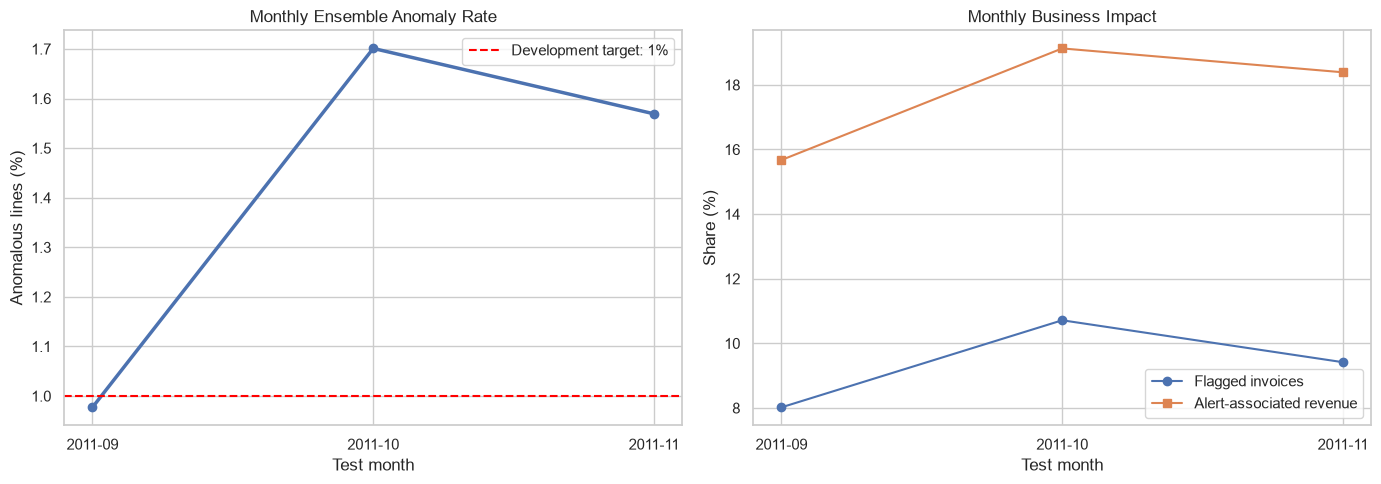

In [115]:
monthly_labels = (
    final_monthly_anomaly_metrics
    .index.astype(str)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    monthly_labels,
    final_monthly_anomaly_metrics[
        "AnomalyRatePercent"
    ],
    marker="o",
    linewidth=2.5
)

axes[0].axhline(
    1.0,
    color="red",
    linestyle="--",
    label="Development target: 1%"
)

axes[0].set_title(
    "Monthly Ensemble Anomaly Rate"
)
axes[0].set_xlabel("Test month")
axes[0].set_ylabel("Anomalous lines (%)")
axes[0].legend()

axes[1].plot(
    monthly_labels,
    final_monthly_anomaly_metrics[
        "FlaggedInvoiceRatePercent"
    ],
    marker="o",
    label="Flagged invoices"
)

axes[1].plot(
    monthly_labels,
    final_monthly_anomaly_metrics[
        "AlertRevenueSharePercent"
    ],
    marker="s",
    label="Alert-associated revenue"
)

axes[1].set_title(
    "Monthly Business Impact"
)
axes[1].set_xlabel("Test month")
axes[1].set_ylabel("Share (%)")
axes[1].legend()

fig.tight_layout()

fig.savefig(
    anomaly_figure_folder
    / "monthly_anomaly_monitoring.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Cases and revenue by category

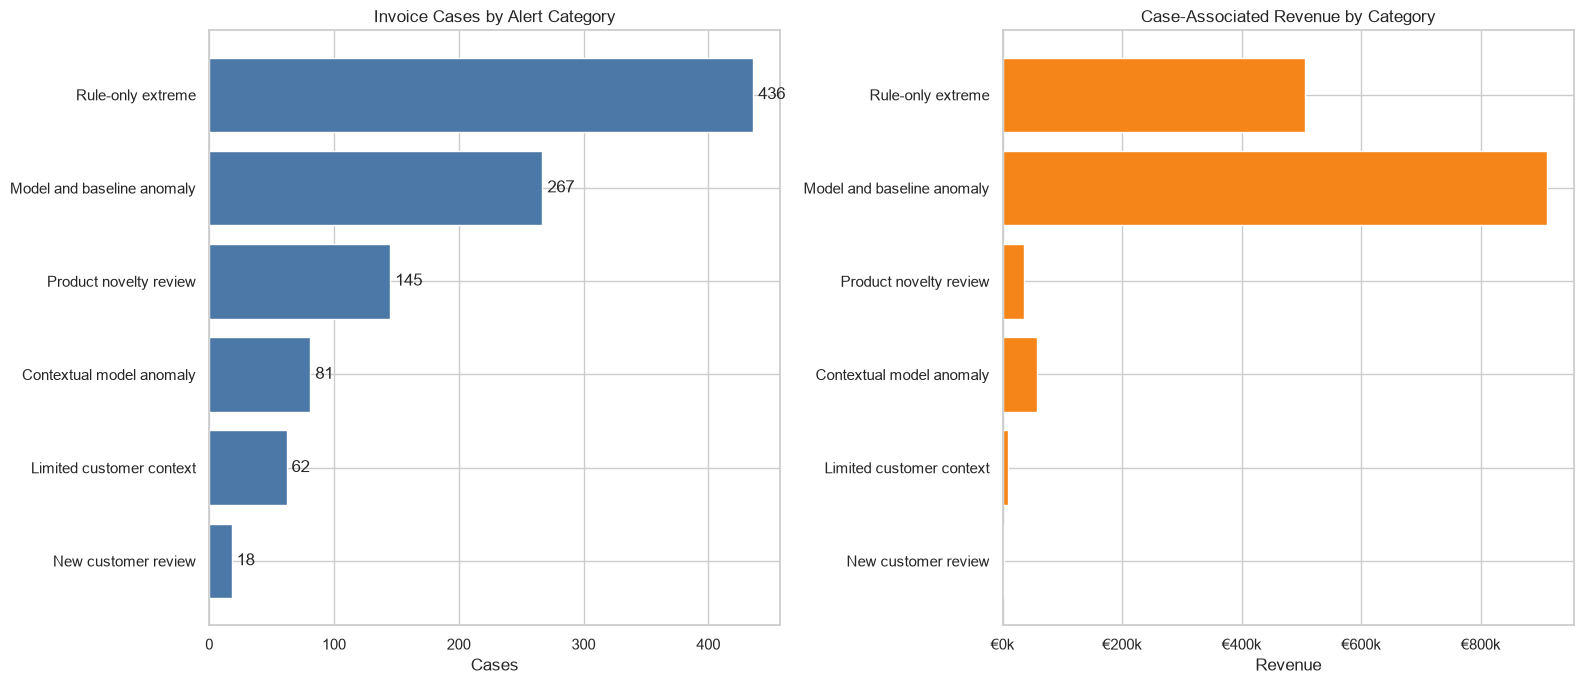

In [116]:
category_plot_df = (
    final_invoice_alert_cases
    .groupby("PrimaryAlertCategory")
    .agg(
        Cases=("CaseID", "size"),
        CaseRevenue=(
            "AnalysedInvoiceRevenue",
            "sum"
        )
    )
    .sort_values("Cases")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

axes[0].barh(
    category_plot_df.index,
    category_plot_df["Cases"],
    color="#4C78A8"
)

axes[0].set_title(
    "Invoice Cases by Alert Category"
)
axes[0].set_xlabel("Cases")
axes[0].set_ylabel("")

for position, value in enumerate(
    category_plot_df["Cases"]
):
    axes[0].text(
        value,
        position,
        f" {value:,}",
        va="center"
    )

axes[1].barh(
    category_plot_df.index,
    category_plot_df["CaseRevenue"],
    color="#F58518"
)

axes[1].set_title(
    "Case-Associated Revenue by Category"
)
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("")

axes[1].xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: (
            f"€{value / 1_000:,.0f}k"
        )
    )
)

fig.tight_layout()

fig.savefig(
    anomaly_figure_folder
    / "alert_category_business_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

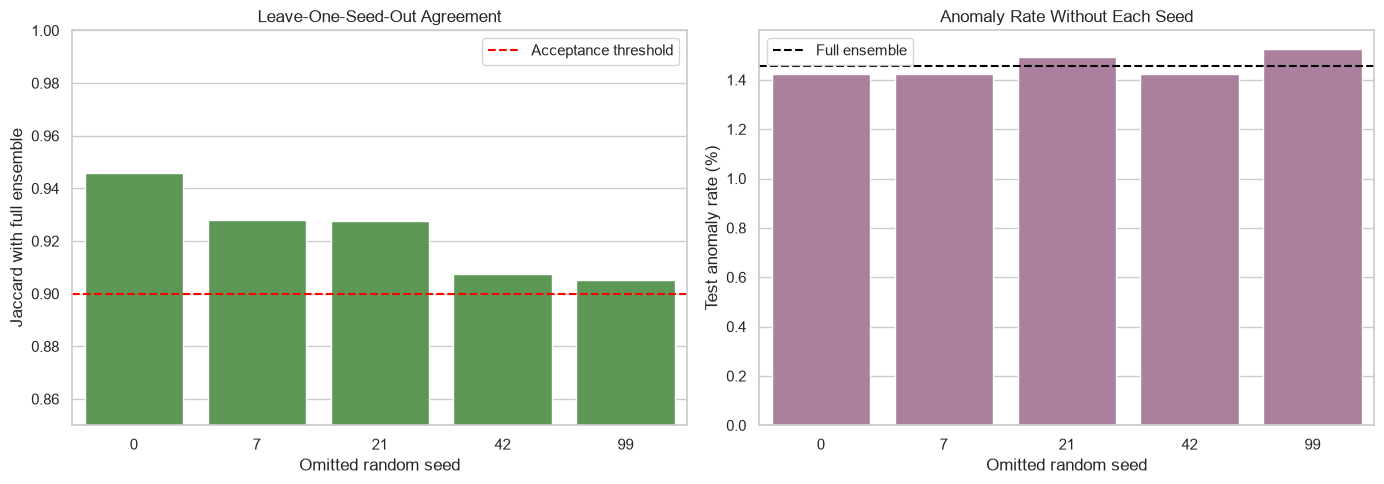

In [117]:
ensemble_stability_plot = (
    ensemble_leave_one_out_stability.copy()
)

ensemble_stability_plot[
    "OmittedSeedLabel"
] = (
    ensemble_stability_plot[
        "OmittedSeed"
    ].astype(str)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=ensemble_stability_plot,
    x="OmittedSeedLabel",
    y="JaccardWithFullEnsemble",
    color="#54A24B",
    ax=axes[0]
)

axes[0].axhline(
    0.90,
    color="red",
    linestyle="--",
    label="Acceptance threshold"
)

axes[0].set_ylim(0.85, 1.0)
axes[0].set_title(
    "Leave-One-Seed-Out Agreement"
)
axes[0].set_xlabel("Omitted random seed")
axes[0].set_ylabel("Jaccard with full ensemble")
axes[0].legend()

sns.barplot(
    data=ensemble_stability_plot,
    x="OmittedSeedLabel",
    y="TestAnomalyRatePercent",
    color="#B279A2",
    ax=axes[1]
)

axes[1].axhline(
    float(
        ensemble_summary[
            "Test anomaly rate (%)"
        ]
    ),
    color="black",
    linestyle="--",
    label="Full ensemble"
)

axes[1].set_title(
    "Anomaly Rate Without Each Seed"
)
axes[1].set_xlabel("Omitted random seed")
axes[1].set_ylabel("Test anomaly rate (%)")
axes[1].legend()

fig.tight_layout()

fig.savefig(
    anomaly_figure_folder
    / "ensemble_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Anomaly-score distribution

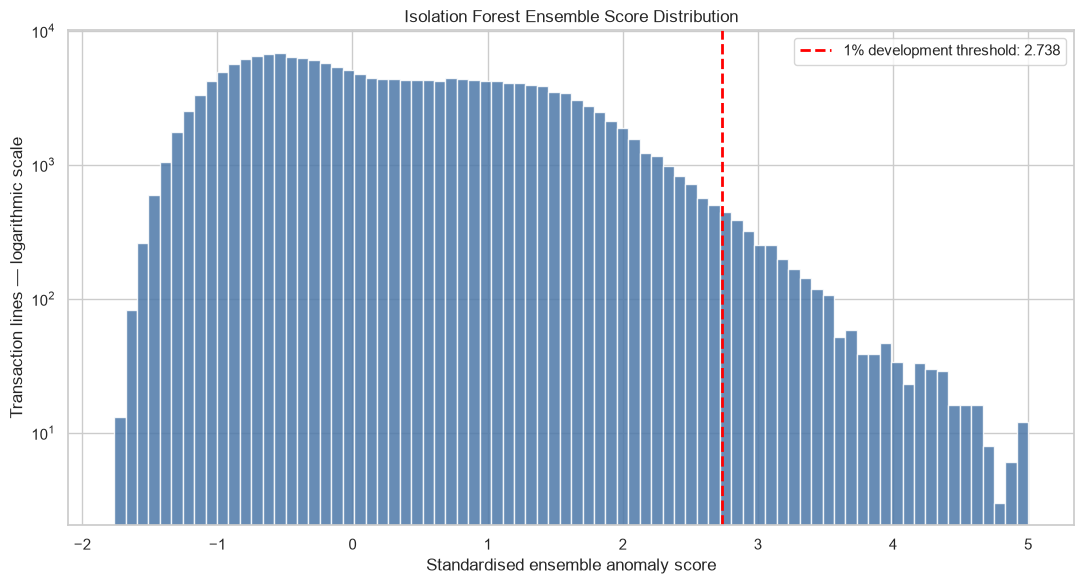

In [118]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.hist(
    ensemble_test_scores,
    bins=80,
    color="#4C78A8",
    alpha=0.85
)

ax.axvline(
    ensemble_score_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=(
        f"1% development threshold: "
        f"{ensemble_score_threshold:.3f}"
    )
)

ax.set_yscale("log")
ax.set_title(
    "Isolation Forest Ensemble Score Distribution"
)
ax.set_xlabel(
    "Standardised ensemble anomaly score"
)
ax.set_ylabel(
    "Transaction lines — logarithmic scale"
)
ax.legend()

fig.tight_layout()

fig.savefig(
    anomaly_figure_folder
    / "ensemble_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
saved_anomaly_figures = sorted(
    anomaly_figure_folder.glob("*.png")
)

for figure_file in saved_anomaly_figures:
    print(figure_file.name)

print(
    "Total figures saved:",
    len(saved_anomaly_figures)
)

alert_category_business_profile.png
ensemble_score_distribution.png
ensemble_stability.png
monthly_anomaly_monitoring.png
Total figures saved: 4


In [120]:
import json
import joblib

anomaly_output_folder = (
    project_root
    / "data"
    / "processed"
    / "anomaly_detection"
)

anomaly_model_folder = (
    project_root
    / "models"
    / "anomaly_detection"
)

anomaly_output_folder.mkdir(
    parents=True,
    exist_ok=True
)

anomaly_model_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [121]:
anomaly_model_package = {
    "model_version": (
        "isolation_forest_ensemble_v1"
    ),

    "algorithm": (
        "Five-seed Isolation Forest "
        "standardised-score ensemble"
    ),

    "imputer": fitted_imputer,

    "forests": ensemble_forests,

    "score_normalisation": (
        seed_score_normalisation
    ),

    "ensemble_score_threshold": float(
        ensemble_score_threshold
    ),

    "feature_columns": list(
        X_anomaly_development.columns
    ),

    "feature_references": (
        final_anomaly_references
    ),

    "baseline_quantile": float(
        BASELINE_QUANTILE
    ),

    "baseline_thresholds": {
        key: float(value)
        for key, value
        in final_baseline_thresholds.items()
    },

    "training_anomaly_rate": 0.01,

    "random_seeds": [
        int(seed)
        for seed in stability_seeds
    ],

    "n_estimators_per_forest": 250,

    "max_samples": 256
}

anomaly_model_file = (
    anomaly_model_folder
    / "isolation_forest_ensemble_v1.joblib"
)

joblib.dump(
    anomaly_model_package,
    anomaly_model_file,
    compress=3
)

print("Saved model:", anomaly_model_file)

Saved model: c:\Github\retail-financial-intelligence\models\anomaly_detection\isolation_forest_ensemble_v1.joblib


In [122]:
model_metadata = {
    "model_version": (
        "isolation_forest_ensemble_v1"
    ),

    "algorithm": (
        "Isolation Forest score ensemble"
    ),

    "model_scope": (
        "Valid positive sale transaction lines; "
        "cancellations, adjustments and service "
        "transactions are handled separately."
    ),

    "development_start": (
        anomaly_development_df[
            "InvoiceDate"
        ].min().isoformat()
    ),

    "development_end": (
        anomaly_development_df[
            "InvoiceDate"
        ].max().isoformat()
    ),

    "test_start": (
        anomaly_test_df[
            "InvoiceDate"
        ].min().isoformat()
    ),

    "test_end": (
        anomaly_test_df[
            "InvoiceDate"
        ].max().isoformat()
    ),

    "development_rows": int(
        len(anomaly_development_df)
    ),

    "test_rows": int(
        len(anomaly_test_df)
    ),

    "feature_count": int(
        len(X_anomaly_development.columns)
    ),

    "feature_columns": list(
        X_anomaly_development.columns
    ),

    "random_seeds": [
        int(seed)
        for seed in stability_seeds
    ],

    "n_estimators_per_forest": 250,
    "max_samples": 256,
    "development_target_rate": 0.01,

    "ensemble_score_threshold": float(
        ensemble_score_threshold
    ),

    "test_model_anomalies": int(
        final_test_alert_lines[
            "IsModelAnomaly"
        ].sum()
    ),

    "test_anomaly_rate_percent": float(
        final_test_alert_lines[
            "IsModelAnomaly"
        ].mean() * 100
    ),

    "test_model_flagged_invoices": int(
        final_test_alert_lines.loc[
            final_test_alert_lines[
                "IsModelAnomaly"
            ],
            "Invoice"
        ].nunique()
    ),

    "final_invoice_cases": int(
        len(final_invoice_alert_cases)
    ),

    "p1_cases": int(
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(1).sum()
    ),

    "p2_cases": int(
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(2).sum()
    ),

    "p3_cases": int(
        final_invoice_alert_cases[
            "HighestAlertPriority"
        ].eq(3).sum()
    ),

    "baseline_quantile": float(
        BASELINE_QUANTILE
    ),

    "baseline_thresholds": {
        key: float(value)
        for key, value
        in final_baseline_thresholds.items()
    },

    "minimum_leave_one_out_jaccard": float(
        ensemble_leave_one_out_stability[
            "JaccardWithFullEnsemble"
        ].min()
    ),

    "minimum_leave_one_out_ari": float(
        ensemble_leave_one_out_stability[
            "AdjustedRandIndex"
        ].min()
    ),

    "minimum_leave_one_out_score_correlation": float(
        ensemble_leave_one_out_stability[
            "ScoreCorrelation"
        ].min()
    ),

    "ensemble_model_accepted": bool(
        ensemble_model_accepted
    )
}

model_metadata_file = (
    anomaly_model_folder
    / "model_metadata.json"
)

with model_metadata_file.open(
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=2
    )

print(
    "Saved metadata:",
    model_metadata_file
)

Saved metadata: c:\Github\retail-financial-intelligence\models\anomaly_detection\model_metadata.json


In [124]:
flagged_line_alerts = (
    final_test_alert_lines.loc[
        final_test_alert_lines[
            "IsAnyAlert"
        ]
    ]
    .copy()
)

monthly_export_df = (
    final_monthly_anomaly_metrics
    .reset_index()
)

monthly_export_df[
    "InvoiceMonth"
] = monthly_export_df[
    "InvoiceMonth"
].astype(str)

ensemble_summary_df = (
    ensemble_summary
    .rename("Value")
    .rename_axis("Metric")
    .reset_index()
)

final_alert_validation_df = (
    final_alert_validation
    .rename("Value")
    .rename_axis("Metric")
    .reset_index()
)

final_case_validation_df = (
    final_case_validation
    .rename("Value")
    .rename_axis("Metric")
    .reset_index()
)

In [125]:
export_files = {
    "anomaly_test_line_scores.csv.gz": (
        final_test_alert_lines
    ),

    "anomaly_flagged_lines.csv.gz": (
        flagged_line_alerts
    ),

    "anomaly_invoice_cases.csv.gz": (
        final_invoice_alert_cases
    ),

    "anomaly_case_summary.csv": (
        final_case_summary
    ),

    "anomaly_monthly_metrics.csv": (
        monthly_export_df
    ),

    "anomaly_candidate_results.csv": (
        anomaly_candidate_results
    ),

    "anomaly_seed_stability.csv": (
        anomaly_seed_stability
    ),

    "anomaly_ensemble_stability.csv": (
        ensemble_leave_one_out_stability
    ),

    "anomaly_ensemble_summary.csv": (
        ensemble_summary_df
    ),

    "anomaly_line_validation.csv": (
        final_alert_validation_df
    ),

    "anomaly_case_validation.csv": (
        final_case_validation_df
    )
}

In [126]:
for filename, export_df in export_files.items():

    output_path = (
        anomaly_output_folder
        / filename
    )

    if filename.endswith(".csv.gz"):
        export_df.to_csv(
            output_path,
            index=False,
            compression="gzip"
        )
    else:
        export_df.to_csv(
            output_path,
            index=False
        )

    print(
        f"Saved {filename}: "
        f"{len(export_df):,} rows"
    )

Saved anomaly_test_line_scores.csv.gz: 187,819 rows
Saved anomaly_flagged_lines.csv.gz: 3,616 rows
Saved anomaly_invoice_cases.csv.gz: 1,009 rows
Saved anomaly_case_summary.csv: 6 rows
Saved anomaly_monthly_metrics.csv: 3 rows
Saved anomaly_candidate_results.csv: 6 rows
Saved anomaly_seed_stability.csv: 5 rows
Saved anomaly_ensemble_stability.csv: 5 rows
Saved anomaly_ensemble_summary.csv: 9 rows
Saved anomaly_line_validation.csv: 6 rows
Saved anomaly_case_validation.csv: 7 rows


In [127]:
manifest_records = []

for filename, export_df in export_files.items():

    output_path = (
        anomaly_output_folder
        / filename
    )

    manifest_records.append({
        "FileName": filename,
        "ArtifactType": "Dataset",
        "Rows": len(export_df),
        "RelativePath": str(
            output_path.relative_to(
                project_root
            )
        ),
        "FileSizeMB": round(
            output_path.stat().st_size
            / 1_000_000,
            3
        )
    })

for model_path, artifact_type in [
    (
        anomaly_model_file,
        "Model package"
    ),
    (
        model_metadata_file,
        "Model metadata"
    )
]:

    manifest_records.append({
        "FileName": model_path.name,
        "ArtifactType": artifact_type,
        "Rows": np.nan,
        "RelativePath": str(
            model_path.relative_to(
                project_root
            )
        ),
        "FileSizeMB": round(
            model_path.stat().st_size
            / 1_000_000,
            3
        )
    })

anomaly_export_manifest = (
    pd.DataFrame(manifest_records)
)

manifest_file = (
    anomaly_output_folder
    / "anomaly_export_manifest.csv"
)

anomaly_export_manifest.to_csv(
    manifest_file,
    index=False
)

anomaly_export_manifest

,FileName,ArtifactType,Rows,RelativePath,FileSizeMB
0,anomaly_test_line_scores.csv.gz,Dataset,187819.0,data\processed\anomaly_detection\anomaly_test_line_scores.csv.gz,9.289
1,anomaly_flagged_lines.csv.gz,Dataset,3616.0,data\processed\anomaly_detection\anomaly_flagged_lines.csv.gz,0.189
2,anomaly_invoice_cases.csv.gz,Dataset,1009.0,data\processed\anomaly_detection\anomaly_invoice_cases.csv.gz,0.070
3,anomaly_case_summary.csv,Dataset,6.0,data\processed\anomaly_detection\anomaly_case_summary.csv,0.001
4,anomaly_monthly_metrics.csv,Dataset,3.0,data\processed\anomaly_detection\anomaly_monthly_metrics.csv,0.000
5,anomaly_candidate_results.csv,Dataset,6.0,data\processed\anomaly_detection\anomaly_candidate_results.csv,0.001
6,anomaly_seed_stability.csv,Dataset,5.0,data\processed\anomaly_detection\anomaly_seed_stability.csv,0.001
7,anomaly_ensemble_stability.csv,Dataset,5.0,data\processed\anomaly_detection\anomaly_ensemble_stability.csv,0.001
8,anomaly_ensemble_summary.csv,Dataset,9.0,data\processed\anomaly_detection\anomaly_ensemble_summary.csv,0.000
9,anomaly_line_validation.csv,Dataset,6.0,data\processed\anomaly_detection\anomaly_line_validation.csv,0.000


In [128]:
reloaded_anomaly_package = (
    joblib.load(anomaly_model_file)
)

assert (
    reloaded_anomaly_package[
        "model_version"
    ]
    == "isolation_forest_ensemble_v1"
)

assert (
    len(
        reloaded_anomaly_package[
            "forests"
        ]
    )
    == 5
)

assert (
    reloaded_anomaly_package[
        "feature_columns"
    ]
    == list(
        X_anomaly_development.columns
    )
)

assert np.isfinite(
    reloaded_anomaly_package[
        "ensemble_score_threshold"
    ]
)

assert anomaly_model_file.exists()
assert model_metadata_file.exists()
assert manifest_file.exists()

print(
    "Model and export validation passed."
)

print(
    "Model size:",
    round(
        anomaly_model_file.stat().st_size
        / 1_000_000,
        2
    ),
    "MB"
)

Model and export validation passed.
Model size: 5.05 MB


### Partial-month exclusion

December 2011 contains only a partial month of transaction data. It was
excluded from model development, threshold selection, validation and final
test evaluation to prevent misleading anomaly-rate comparisons.

The final independent test period is September–November 2011. December
records remain available in the cleaned master dataset for future monitoring
but are not included in the reported model-performance results.

In [134]:
from pathlib import Path

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

reports_folder = project_root / "reports"
reports_folder.mkdir(parents=True, exist_ok=True)

report_file = (
    reports_folder /
    "anomaly_detection_report.md"
)

In [135]:
test_rows = len(final_test_alert_lines)

model_anomaly_lines = int(
    final_test_alert_lines[
        "IsModelAnomaly"
    ].sum()
)

test_anomaly_rate = (
    final_test_alert_lines[
        "IsModelAnomaly"
    ].mean() * 100
)

model_flagged_invoices = (
    final_test_alert_lines.loc[
        final_test_alert_lines[
            "IsModelAnomaly"
        ],
        "Invoice"
    ]
    .nunique()
)

total_cases = len(
    final_invoice_alert_cases
)

priority_counts = (
    final_invoice_alert_cases[
        "CasePriority"
    ]
    .value_counts()
)

p1_cases = int(
    priority_counts.get(
        "P1 - Immediate review", 0
    )
)

p2_cases = int(
    priority_counts.get(
        "P2 - Financial review", 0
    )
)

p3_cases = int(
    priority_counts.get(
        "P3 - Monitor", 0
    )
)

minimum_jaccard = (
    ensemble_leave_one_out_stability[
        "JaccardWithFullEnsemble"
    ].min()
)

minimum_ari = (
    ensemble_leave_one_out_stability[
        "AdjustedRandIndex"
    ].min()
)

minimum_score_correlation = (
    ensemble_leave_one_out_stability[
        "ScoreCorrelation"
    ].min()
)

In [136]:
report_text = f"""
# RetailIQ Anomaly Detection Report

## Executive summary

RetailIQ uses an unsupervised Isolation Forest ensemble to identify unusual
sale transaction lines for financial and operational review.

The independent test period contains {test_rows:,} transaction lines from
September through November 2011. The model identified
{model_anomaly_lines:,} anomalous lines, representing
{test_anomaly_rate:.2f}% of the test population.

The line-level alerts were consolidated into {total_cases:,} invoice-level
cases. Of these, {p1_cases:,} require immediate review, {p2_cases:,} require
financial review and {p3_cases:,} are monitoring cases.

## Data scope

- Development period: December 2009 through August 2011
- Independent test period: September through November 2011
- Test rows: {test_rows:,}
- Partial December 2011 data: excluded from evaluation
- Population: valid product-sale transactions
- Exact reversal pairs and critical data-quality failures: excluded

## Methodology

The solution combines two complementary detection methods:

1. A transparent statistical baseline based on extreme transaction values.
2. A five-seed Isolation Forest ensemble for contextual and multivariate
   anomalies.

The model uses 17 numerical features describing transaction value, quantity,
price, invoice context, product history, customer history and transaction
timing.

No categorical encoder was required because identifiers such as Invoice,
StockCode, CustomerID and TransactionType were not passed directly into the
model. No feature scaling was required for the tree-based Isolation Forest.

## Model configuration

- Algorithm: Isolation Forest ensemble
- Number of models: 5
- Random seeds: 0, 7, 21, 42 and 99
- Trees per model: 250
- Maximum samples per tree: 256
- Development alert threshold: 1%
- Missing-value treatment: median imputation
- Evaluation approach: chronological holdout

## Test results

- Model anomaly lines: {model_anomaly_lines:,}
- Test anomaly rate: {test_anomaly_rate:.2f}%
- Model-flagged invoices: {model_flagged_invoices:,}
- Total actionable invoice cases: {total_cases:,}
- P1 cases: {p1_cases:,}
- P2 cases: {p2_cases:,}
- P3 cases: {p3_cases:,}

## Model stability

The five-model ensemble was evaluated using leave-one-model-out sensitivity
testing.

- Minimum Jaccard similarity: {minimum_jaccard:.4f}
- Minimum Adjusted Rand Index: {minimum_ari:.4f}
- Minimum anomaly-score correlation: {minimum_score_correlation:.4f}

These results show that the ensemble produces substantially more stable alerts
than relying on a single random seed.

## Alert interpretation

| Priority | Alert category | Recommended owner | Action |
|---|---|---|---|
| P1 | Model and baseline anomaly | Finance and Operations | Review immediately |
| P2 | Rule-only extreme | Finance Control | Validate the financial transaction |
| P2 | Contextual model anomaly | Finance Analytics | Investigate unusual transaction context |
| P3 | Product novelty review | Merchandising | Confirm new or unusual product activity |
| P3 | Limited customer context | Data Quality / Customer Operations | Investigate missing customer information |
| P3 | New customer review | Customer Operations / Credit Control | Monitor new-customer activity |

## Business recommendations

1. Investigate P1 cases first because both detection methods identified them.
2. Reconcile P2 financial cases against invoices, prices, quantities and
   accounting records.
3. Route product-novelty alerts to merchandising instead of treating them as
   confirmed errors.
4. Resolve missing CustomerID cases to improve traceability.
5. Record review outcomes to create labelled data for future supervised model
   evaluation.
6. Monitor anomaly rates monthly and investigate material changes in the alert
   rate.

## Limitations

- The dataset does not contain confirmed anomaly or fraud labels.
- Alerts represent unusual activity, not confirmed fraud, error or loss.
- The development threshold is operational rather than label-optimised.
- New products and missing customer identifiers can generate legitimate
  novelty alerts.
- December 2011 is incomplete and therefore excluded from model evaluation.
- Model performance should be reassessed after analyst review outcomes become
  available.

## Partial-month exclusion

December 2011 contains only a partial month of transaction data. It was
excluded from model development, threshold selection, validation and final
test evaluation to prevent misleading comparisons.

The December records remain available in the cleaned master dataset for future
monitoring.

## Visualisations

![Monthly anomaly monitoring](figures/anomaly_detection/monthly_anomaly_monitoring.png)

![Alert category profile](figures/anomaly_detection/alert_category_business_profile.png)

![Ensemble stability](figures/anomaly_detection/ensemble_stability.png)

![Ensemble score distribution](figures/anomaly_detection/ensemble_score_distribution.png)

## Output artifacts

The project exports:

- line-level anomaly scores;
- flagged transaction lines;
- prioritised invoice cases;
- alert-category summaries;
- monthly monitoring metrics;
- model-stability results;
- the serialised five-model ensemble;
- model metadata and feature definitions.
"""

report_file.write_text(
    report_text.strip() + "\n",
    encoding="utf-8"
)

print("Report saved to:", report_file)

Report saved to: c:\Github\retail-financial-intelligence\reports\anomaly_detection_report.md


In [137]:
assert report_file.exists()
assert report_file.stat().st_size > 0

print(
    report_file.read_text(
        encoding="utf-8"
    )[:1000]
)

# RetailIQ Anomaly Detection Report

## Executive summary

RetailIQ uses an unsupervised Isolation Forest ensemble to identify unusual
sale transaction lines for financial and operational review.

The independent test period contains 187,819 transaction lines from
September through November 2011. The model identified
2,737 anomalous lines, representing
1.46% of the test population.

The line-level alerts were consolidated into 1,009 invoice-level
cases. Of these, 267 require immediate review, 517 require
financial review and 225 are monitoring cases.

## Data scope

- Development period: December 2009 through August 2011
- Independent test period: September through November 2011
- Test rows: 187,819
- Partial December 2011 data: excluded from evaluation
- Population: valid product-sale transactions
- Exact reversal pairs and critical data-quality failures: excluded

## Methodology

The solution combines two complementary detection methods:

1. A transparent statistical baseline based o